# Máquinas Térmicas - Lección 9
## Tecnología para la Combustión

**Autor:** Camilo Bayona
**Fecha:** 13/08/2025

*Las Lecciones 7 y 8 dieron la teoría: cuánto aire pide la estequiometría y a qué velocidad ocurre el encuentro molecular. Esta lección recorre las **tecnologías** que hacen posible ese encuentro en equipos reales — y cada una se explica por el **fenómeno físico-químico** que ataca.*

### Objetivos de aprendizaje
1. Identificar los **cuatro obstáculos físicos** que separan al combustible del oxígeno (área de contacto, ceniza, temperatura, mezcla) y relacionarlos con la teoría de las Lecciones 7-8.
2. Explicar el funcionamiento de las tecnologías de combustión de sólidos (parrillas, lechos fluidizados, hogares ciclónicos), líquidos (atomizadores) y gases (quemadores) a partir del obstáculo que cada una resuelve.
3. Dimensionar los parámetros básicos de un atomizador y de un lecho fluidizado, y evaluar el efecto del precalentamiento y los economizadores sobre la eficiencia.
4. Analizar el compromiso entre combustión completa y formación de NOx en el aire escalonado.

In [1]:
# Instalación solo en Google Colab; en el entorno local del curso es un no-op
import sys
if "google.colab" in sys.modules:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "matplotlib", "ipywidgets", "numpy", "scipy", "CoolProp"], check=True)

In [2]:
# === Setup =================================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import (Rectangle, Circle, FancyArrowPatch, FancyBboxPatch,
                                Polygon, Wedge, Annulus)
from scipy.integrate import odeint
from scipy.optimize import brentq
from ipywidgets import (interact, interactive_output, FloatSlider, IntSlider,
                        FloatLogSlider, Dropdown, Checkbox, Play, HBox, VBox, jslink)
from IPython.display import display
from CoolProp.CoolProp import PropsSI

R = 8.314  # J/(mol·K)
# Paleta del proyecto (idéntica a las Lecciones 7, 8 y 8b)
COL = {"fuel": "#2a78d6", "O2": "#e34948", "H2O": "#1baf7a", "CO2": "#eda100",
       "SO2": "#4a3aa7", "llama": "#eb6834", "N2": "#8a8a86", "ceniza": "#c3c2b7",
       "tinta": "#3a3a38"}

# Tablas de entalpía sensible de gas ideal h(T)-h(298) [J/mol] con CoolProp (patrón de la Lección 7)
T_GRID = np.linspace(298.15, 3200.0, 240)
H_SENS = {}
for _fl in ["CO2", "Water", "Nitrogen", "Oxygen", "Methane"]:
    _cp = np.array([PropsSI("Cp0molar", "T", float(_t), "P", 101325.0, _fl) for _t in T_GRID])
    H_SENS[_fl] = np.concatenate([[0.0], np.cumsum(np.diff(T_GRID) * 0.5 * (_cp[1:] + _cp[:-1]))])
def h_sens(fluido, T):   # J/mol respecto a 298.15 K (las diferencias eliminan la referencia)
    return np.interp(T, T_GRID, H_SENS[fluido])

print(f"Setup OK — tablas cp⁰ de CoolProp para {len(H_SENS)} gases")

Setup OK — tablas cp⁰ de CoolProp para 5 gases


## 1. Introducción

La combustión ha sido una parte integral de la tecnología humana desde el descubrimiento del fuego. Los primeros humanos utilizaban la combustión para calentar sus hogares, cocinar alimentos y producir luz. Con el tiempo, la tecnología de la combustión se ha desarrollado y refinado para una variedad de aplicaciones, desde la producción de energía en centrales eléctricas hasta la propulsión de vehículos y aeronaves. A lo largo de la historia, la tecnología de la combustión ha evolucionado para ser más eficiente y menos dañina para el medio ambiente.

### 1.1 El marco de esta lección: cuatro obstáculos, una teoría

La Lección 8 mostró que la velocidad de combustión es proporcional al **encuentro molecular**, $r = k\,[F][O_2]$ con $k = A e^{-E_a/RT}$, y la Lección 7 fijó la meta: contacto **estequiométrico** ($\lambda \approx 1$) para liberar el máximo calor. En un equipo real, cuatro obstáculos impiden ese encuentro:

| # | Obstáculo | Fenómeno físico | Tecnologías que lo atacan | Teoría |
|---|---|---|---|---|
| 1 | **Falta de área de contacto** | el combustible sólido/líquido no es molecular: solo reacciona su superficie, $A/V \propto 1/d$ | pulverización, atomización, proyección, lecho fluidizado | L8 §3-4 |
| 2 | **La ceniza impermeabiliza** | la costra inerte obliga al O₂ a difundir para llegar al carbono | soplado con vapor, parrilla viajera, atrición en lecho fluidizado | L8 §4 |
| 3 | **Temperatura insuficiente** | Arrhenius apaga $k$; la mezcla fría no se enciende | precalentadores de aire, economizadores, arcos refractarios | L6, L8 §7 |
| 4 | **Mezcla pobre** | hay O₂, pero no donde está el combustible (macro/micromezcla) | turbulencia, remolinos (swirl), aire secundario, premezcla | L8 §5-6 |

Las secciones 2–5 visualizan cada fenómeno con un widget; las secciones 6–8 recorren las tecnologías de sólidos, líquidos y gases señalando **qué obstáculo ataca** cada una. Las tres **T** clásicas del diseño de hogares — *Temperatura, Tiempo (de residencia), Turbulencia* — son exactamente los obstáculos 3, 1-2 y 4.

*(Las propiedades y el origen de los combustibles — carbón, petróleo, gas — ya se estudiaron en la **Lección 4**; aquí solo se citan los datos que cada tecnología necesita.)*

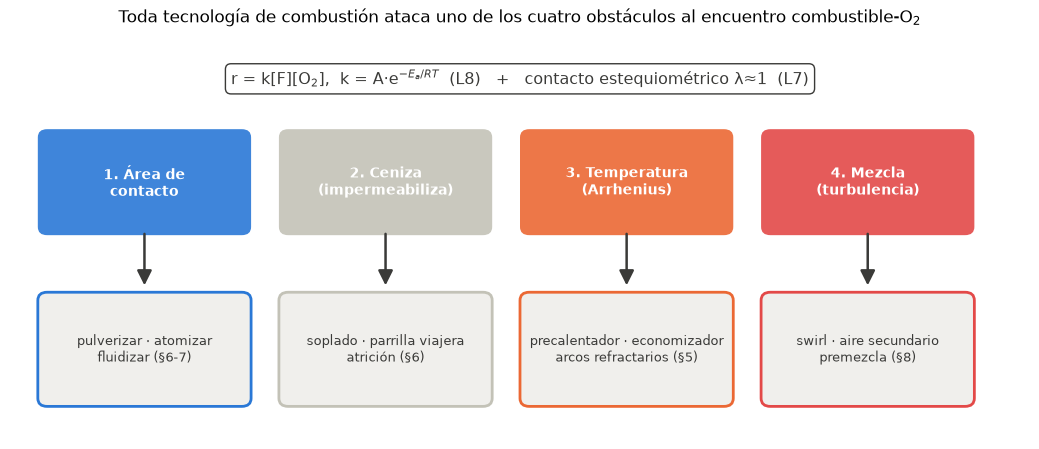

In [3]:
# Mapa de la lección — diagrama generado por código
fig, ax = plt.subplots(figsize=(10.5, 4.6))
obst = [("1. Área de\ncontacto", COL["fuel"]), ("2. Ceniza\n(impermeabiliza)", COL["ceniza"]),
        ("3. Temperatura\n(Arrhenius)", COL["llama"]), ("4. Mezcla\n(turbulencia)", COL["O2"])]
tecs = ["pulverizar · atomizar\nfluidizar (§6-7)", "soplado · parrilla viajera\natrición (§6)",
        "precalentador · economizador\narcos refractarios (§5)", "swirl · aire secundario\npremezcla (§8)"]
for i, ((nom, c), tec) in enumerate(zip(obst, tecs)):
    x = 0.4 + i * 2.6
    ax.add_patch(FancyBboxPatch((x, 2.6), 2.1, 1.1, boxstyle="round,pad=0.1",
                                fc=c, ec="none", alpha=0.9))
    ax.text(x + 1.05, 3.15, nom, ha="center", va="center", fontsize=10,
            color="white", fontweight="bold")
    ax.add_patch(FancyBboxPatch((x, 0.5), 2.1, 1.2, boxstyle="round,pad=0.1",
                                fc="#f0efec", ec=c, lw=2))
    ax.text(x + 1.05, 1.1, tec, ha="center", va="center", fontsize=9, color=COL["tinta"])
    ax.add_patch(FancyArrowPatch((x + 1.05, 2.55), (x + 1.05, 1.85),
                                 arrowstyle="-|>", mutation_scale=22, color=COL["tinta"], lw=1.8))
ax.text(5.5, 4.35, "r = k[F][O$_2$],  k = A·e$^{-E_a/RT}$  (L8)   +   contacto estequiométrico λ≈1  (L7)",
        ha="center", fontsize=11.5, color=COL["tinta"],
        bbox=dict(boxstyle="round,pad=0.35", fc="white", ec=COL["tinta"]))
ax.set_xlim(0, 11); ax.set_ylim(0, 5); ax.axis("off")
ax.set_title("Toda tecnología de combustión ataca uno de los cuatro obstáculos al encuentro combustible-O$_2$")
plt.tight_layout(); plt.show()

## 2. Fenómeno 1 — El área de contacto combustible-aire

Un gas reacciona en todo su volumen; un sólido o un líquido solo en su **superficie**. Para una partícula o gota de diámetro $d$, la superficie específica crece al dividir:

$$\frac{A}{V} = \frac{\pi d^2}{\pi d^3/6} = \frac{6}{d} \qquad\Rightarrow\qquad
A_{total}(n\ \text{fragmentos}) = A_0\, n^{1/3}$$

y el tiempo de consumo depende del régimen que controle (Lección 8, §4):

$$\tau_{cinético} \propto d \qquad\qquad \tau_{difusivo} = \frac{d^2}{K} \quad (\text{ley } d^2)$$

donde $K$ [mm²/s] es la constante de evaporación/quemado. **Dividir una gota de 1 mm en mil gotas de 100 μm multiplica el área por 10 y reduce el tiempo de quemado difusivo por 100** — esa es la razón de ser de la pulverización de carbón y de los atomizadores de la sección 7.

In [ ]:
# WIDGET 1 — interacción combustible-aire: fragmentación, área y tiempo de quemado
rng1 = np.random.default_rng(3)
O2_POS = rng1.uniform(0, 10, (260, 2))

def contacto(D0_mm=10.0, log10_n=0.0, regimen="difusivo (τ ∝ d²)"):
    n = int(round(10 ** log10_n))
    d = D0_mm / n ** (1 / 3)                       # diámetro de cada fragmento [mm]
    area_x = n ** (1 / 3)
    K = 1.0                                        # mm²/s (constante de quemado, ilustrativa)
    tau = d**2 / K if regimen.startswith("dif") else d / 0.5
    tau0 = D0_mm**2 / K if regimen.startswith("dif") else D0_mm / 0.5
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.5, 4.9),
                                   gridspec_kw={"width_ratios": [1, 1.25]})
    # --- panel izquierdo: la masa de combustible fragmentada, rodeada de O2 ---
    ax0.scatter(O2_POS[:, 0], O2_POS[:, 1], s=12, color=COL["O2"], alpha=0.6, label="O$_2$")
    k = min(n, 400)                                # se dibuja una muestra si n es enorme
    lado = int(np.ceil(np.sqrt(k)))
    r_vis = 0.5 * (D0_mm / 10) * 3.0 / n ** (1 / 3)
    for j in range(k):
        cx = 5 + (j % lado - (lado - 1) / 2) * 2.2 * r_vis * 1.15
        cy = 5 + (j // lado - (lado - 1) / 2) * 2.2 * r_vis * 1.15
        ax0.add_patch(Circle((cx, cy), r_vis, fc=COL["fuel"], ec="white", lw=0.4))
    ax0.set_title(f"{n} fragmento(s) de d = {d:.3g} mm" + (" (muestra de 400)" if n > 400 else ""))
    ax0.set_xlim(0, 10); ax0.set_ylim(0, 10); ax0.set_aspect("equal"); ax0.axis("off")
    ax0.legend(loc="lower left", fontsize=9)
    # --- panel derecho: tiempo de quemado vs diámetro ---
    ds = np.logspace(-2, np.log10(D0_mm), 200)
    ax1.loglog(ds, ds**2 / K, color=COL["llama"], lw=2.2, label="difusivo  τ = d²/K")
    ax1.loglog(ds, ds / 0.5, color=COL["fuel"], lw=2.2, ls="--", label="cinético  τ ∝ d")
    ax1.plot(d, tau, "o", ms=10, color=COL["O2"], mec="white", mew=1.5, zorder=5)
    ax1.annotate(f"área ×{area_x:.1f}\nτ = {tau:.3g} s  ({tau0/tau:.0f}× más rápido)",
                 xy=(d, tau), xytext=(d * 1.8, tau * 6), fontsize=10, color=COL["tinta"],
                 arrowprops=dict(arrowstyle="->", color=COL["tinta"], lw=1))
    ax1.set_xlabel("diámetro del fragmento d [mm]"); ax1.set_ylabel("tiempo de quemado τ [s]")
    ax1.set_title("Dividir el combustible acelera su consumo")
    ax1.legend(); ax1.grid(alpha=0.25, which="both")
    plt.tight_layout(); plt.show()

interact(contacto,
         D0_mm=FloatSlider(10.0, min=1, max=50, step=1, description="D₀ [mm]"),
         log10_n=FloatSlider(2.0, min=0, max=6, step=0.25, description="log₁₀ n"),
         regimen=Dropdown(options=["difusivo (τ ∝ d²)", "cinético (τ ∝ d)"], description="régimen"));

interactive(children=(FloatSlider(value=10.0, description='D₀ [mm]', max=50.0, min=1.0, step=1.0), FloatSlider…

## 3. Fenómeno 2 — La ceniza impermeabiliza el combustible

Al quemarse una partícula de carbón, la materia mineral **no** desaparece: queda como una **costra porosa de ceniza** alrededor del núcleo de carbono que aún no reacciona. El O₂ ya no llega libremente a la superficie reactiva: debe **difundir** a través de la costra, y la resistencia crece con su espesor. Es el **modelo de núcleo menguante** (*shrinking core*). Con $y = r_c/R = (1-X)^{1/3}$ (radio adimensional del núcleo, $X$ = conversión), las dos resistencias en serie dan:

$$\frac{dy}{dt} = -\frac{1}{\tau_r + 6\,\tau_a\, y\,(1-y)}$$

donde $\tau_r = \dfrac{\rho_B R}{b\,k_s\,C_{O_2}}$ [s] es el tiempo característico del control **cinético** (superficie limpia) y $\tau_a = \dfrac{\rho_B R^2}{6\,b\,D_e\,C_{O_2}}$ [s] el del control **difusivo por la ceniza** ($D_e$ = difusividad efectiva de la costra). En los límites se recuperan las soluciones clásicas de Levenspiel: $t/\tau_r = 1-(1-X)^{1/3}$ y $t/\tau_a = 1 - 3(1-X)^{2/3} + 2(1-X)$.

**Este fenómeno explica una familia entera de tecnologías**: las boquillas de vapor de la parrilla fija *soplan* la ceniza, la parrilla viajera la *descarga continuamente*, y el lecho fluidizado la *desgasta por fricción* (atrición) entre partículas — todas mantienen $\tau_a$ pequeño para que la partícula termine de quemarse dentro de su tiempo de residencia.

In [5]:
# WIDGET 2 — núcleo menguante: la costra de ceniza frena la conversión
def nucleo_menguante(tau_r=30.0, tau_a=120.0, t_actual=60.0):
    t_max = 3.5 * (tau_r + tau_a)
    t = np.linspace(0, t_max, 700)
    def dydt_con(y, t): return -1.0 / (tau_r + 6 * tau_a * max(y, 1e-9) * (1 - min(y, 1.0)))
    def dydt_sin(y, t): return -1.0 / tau_r
    y_con = np.clip(odeint(dydt_con, 1.0, t)[:, 0], 0, 1)
    y_sin = np.clip(odeint(dydt_sin, 1.0, t)[:, 0], 0, 1)
    X_con, X_sin = 1 - y_con**3, 1 - y_sin**3
    i = np.searchsorted(t, min(t_actual, t_max - 1e-9))
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.5, 4.9),
                                   gridspec_kw={"width_ratios": [1, 1.3]})
    # --- partícula animada (caso con ceniza) ---
    ax0.add_patch(Circle((0, 0), 1.0, fc=COL["ceniza"], ec=COL["tinta"], lw=1.5))
    ax0.add_patch(Circle((0, 0), max(y_con[i], 0.001), fc=COL["tinta"], ec="none"))
    for ang in np.linspace(0, 2 * np.pi, 10, endpoint=False):
        x0, y0 = 1.45 * np.cos(ang), 1.45 * np.sin(ang)
        x1, y1 = 1.08 * np.cos(ang), 1.08 * np.sin(ang)
        ax0.add_patch(FancyArrowPatch((x0, y0), (x1, y1), arrowstyle="-|>",
                                      mutation_scale=11, color=COL["O2"], lw=1.2))
    ax0.text(0, -1.75, "el O$_2$ (rojo) debe atravesar la costra de ceniza (gris)\npara llegar al núcleo de carbono (negro)",
             ha="center", fontsize=9, color=COL["tinta"])
    ax0.set_title(f"t = {t[i]:.0f} s | núcleo r$_c$/R = {y_con[i]:.2f} | X = {X_con[i]:.0%}")
    ax0.set_xlim(-1.9, 1.9); ax0.set_ylim(-2.1, 1.9); ax0.set_aspect("equal"); ax0.axis("off")
    # --- curvas de conversión ---
    ax1.plot(t, X_con, color=COL["tinta"], lw=2.4, label="ceniza adherida (difusión + cinética)")
    ax1.plot(t, X_sin, color=COL["H2O"], lw=2.4, ls="--", label="con remoción de ceniza (solo cinética)")
    ax1.axvline(t[i], color=COL["tinta"], ls=":", lw=1)
    ax1.plot(t[i], X_con[i], "o", ms=8, color=COL["tinta"], mec="white", mew=1.2)
    i99_con = np.searchsorted(X_con, 0.99); i99_sin = np.searchsorted(X_sin, 0.99)
    txt99 = (f"99 % de conversión: {t[min(i99_sin, len(t)-1)]:.0f} s limpia vs "
             f"{t[min(i99_con, len(t)-1)]:.0f} s con costra" if X_con[-1] >= 0.99
             else "con costra NO alcanza 99 % en la ventana")
    ax1.set_title(txt99, fontsize=10)
    ax1.set_xlabel("tiempo [s]"); ax1.set_ylabel("conversión X")
    ax1.set_ylim(0, 1.05); ax1.legend(loc="lower right", fontsize=9); ax1.grid(alpha=0.25)
    ax1.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.show()

play2 = Play(value=60, min=0, max=500, step=10, interval=150)
t_sl = FloatSlider(60.0, min=0, max=500, step=5, description="t [s]")
jslink((play2, "value"), (t_sl, "value"))
tr_sl = FloatSlider(30.0, min=5, max=100, step=5, description="τ_r [s]")
ta_sl = FloatSlider(120.0, min=0, max=400, step=10, description="τ_a [s]")
out2 = interactive_output(nucleo_menguante, {"tau_r": tr_sl, "tau_a": ta_sl, "t_actual": t_sl})
display(VBox([HBox([play2, t_sl]), HBox([tr_sl, ta_sl]), out2]))

**Explora con el widget:** sube $\tau_a$ (ceniza densa, poco porosa) y observa cómo la curva negra se dobla — la partícula "se ahoga" en su propia costra; con $\tau_a \to 0$ (remoción perfecta) ambas curvas coinciden. En un hogar real, si el tiempo de residencia de la partícula es menor que su tiempo de conversión, el carbono sale **sin quemar** en la ceniza: pérdida directa de eficiencia de combustión ($\eta = Q_f/Q_{ch}$, Lección 7 §2.4).

## 4. Fenómeno 3 — Temperatura: precalentamiento y economizadores

Por Arrhenius (Lecciones 6 y 8), la constante cinética se apaga exponencialmente con la temperatura: aire frío = ignición lenta, llama inestable. Y el balance de energía de la caldera dice que la mayor pérdida es el **calor sensible de los gases que salen por la chimenea**:

$$\eta_{caldera} \approx 1 - \frac{\dot m_{gases}\,\bar c_{p,g}\,(T_{chimenea} - T_{amb})}{\dot m_f\, LHV}$$

Dos tecnologías recuperan ese calor **antes** de perderlo:

- **Economizador**: los gases precalientan el **agua de alimentación** de la caldera.
- **Precalentador de aire** (p. ej. regenerativo Ljungström): los gases precalientan el **aire de combustión**, lo que además sube la temperatura de llama y acelera la ignición (obstáculo 3).

El efecto es doble y se cuantifica con las herramientas de la Lección 7: cada grado que baja $T_{chimenea}$ es eficiencia ganada, y cada grado que sube $T_{aire}$ se suma a la entalpía de entrada, elevando $T_{ad}$ y encogiendo el retardo de ignición $\tau_{ig} \propto e^{E_a/RT}$ (Lección 8 §7).

In [6]:
# WIDGET 3 — precalentamiento de aire y economizador (CH4 con aire, cp reales de CoolProp)
NU_CH4 = 2.0                                   # mol O2 por mol CH4
DHC_CH4 = 802.3e3                              # J/mol, LHV del CH4 (L7)
N_PROD = {"CO2": 1.0, "Water": 2.0, "Nitrogen": 3.76 * NU_CH4}
N_AIRE = {"Oxygen": NU_CH4, "Nitrogen": 3.76 * NU_CH4}

def T_llama(T_aire_K, lam=1.0):
    n_air = {k: v * lam for k, v in N_AIRE.items()}
    E_in = DHC_CH4 + sum(n * (h_sens(f, T_aire_K) - h_sens(f, 298.15)) for f, n in n_air.items())
    prods = dict(N_PROD); prods["Nitrogen"] = 3.76 * NU_CH4 * lam
    prods["Oxygen"] = NU_CH4 * (lam - 1)
    def residuo(T):
        return sum(n * (h_sens(f, T) - h_sens(f, 298.15)) for f, n in prods.items()) - E_in
    return brentq(residuo, 300, 3190)

def precalentamiento(T_aire_C=200.0, T_chimenea_C=180.0, lam=1.1):
    T_air = T_aire_C + 273.15
    # eficiencia vs T de chimenea (pérdida sensible de los gases por mol de CH4)
    Tch = np.linspace(80, 420, 120) + 273.15
    prods = {"CO2": 1.0, "Water": 2.0, "Nitrogen": 3.76 * NU_CH4 * lam, "Oxygen": NU_CH4 * (lam - 1)}
    perd = np.array([sum(n * (h_sens(f, T) - h_sens(f, 298.15)) for f, n in prods.items())
                     for T in Tch])
    eta = 1 - perd / DHC_CH4
    eta_act = np.interp(T_chimenea_C + 273.15, Tch, eta)
    eta_300 = np.interp(300 + 273.15, Tch, eta)
    ahorro = (1 / eta_300 - 1 / eta_act) / (1 / eta_300) * 100     # % combustible ahorrado vs chimenea a 300 °C
    # temperatura de llama vs T de aire
    Tas = np.linspace(25, 450, 30) + 273.15
    Tads = np.array([T_llama(T, lam) for T in Tas])
    Tad_act = T_llama(T_air, lam)
    tau_rel = np.exp(120e3 / R * (1 / T_air - 1 / 298.15))          # τ_ig(T_aire)/τ_ig(25 °C), Ea=120 kJ/mol
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.5, 4.9))
    ax0.plot(Tch - 273.15, eta * 100, color=COL["fuel"], lw=2.4)
    ax0.plot(T_chimenea_C, eta_act * 100, "o", ms=10, color=COL["O2"], mec="white", mew=1.5)
    ax0.annotate(f"η = {eta_act*100:.1f} %\ncombustible ahorrado vs 300 °C: {ahorro:.1f} %",
                 xy=(T_chimenea_C, eta_act * 100), xytext=(140, eta.min() * 100 + 1.2),
                 fontsize=10, color=COL["tinta"],
                 arrowprops=dict(arrowstyle="->", color=COL["tinta"], lw=1))
    ax0.set_xlabel("T de gases en chimenea [°C]"); ax0.set_ylabel("η caldera (solo pérdida sensible) [%]")
    ax0.set_title("El economizador/precalentador BAJA T$_{chimenea}$ → sube η")
    ax0.grid(alpha=0.25); ax0.spines[["top", "right"]].set_visible(False)
    ax1.plot(Tas - 273.15, Tads, color=COL["llama"], lw=2.4)
    ax1.plot(T_aire_C, Tad_act, "o", ms=10, color=COL["O2"], mec="white", mew=1.5)
    ax1.annotate(f"T$_{{ad}}$ = {Tad_act:.0f} K (+{Tad_act - T_llama(298.15, lam):.0f} K)\n"
                 f"k de Arrhenius ×{1/tau_rel:.1e} vs aire a 25 °C\n(por eso la mezcla fría no enciende)",
                 xy=(T_aire_C, Tad_act), xytext=(60, Tads.max() - 90), fontsize=10,
                 color=COL["tinta"], arrowprops=dict(arrowstyle="->", color=COL["tinta"], lw=1))
    ax1.set_xlabel("T del aire precalentado [°C]"); ax1.set_ylabel("T$_{ad}$ [K]")
    ax1.set_title("El aire caliente SUBE la T de llama y acelera Arrhenius")
    ax1.grid(alpha=0.25); ax1.spines[["top", "right"]].set_visible(False)
    plt.suptitle(f"CH$_4$ con aire, λ = {lam:.2f}", y=1.01, fontsize=11)
    plt.tight_layout(); plt.show()

interact(precalentamiento,
         T_aire_C=FloatSlider(200, min=25, max=450, step=5, description="T aire [°C]"),
         T_chimenea_C=FloatSlider(180, min=90, max=400, step=5, description="T chim. [°C]"),
         lam=FloatSlider(1.1, min=1.0, max=1.6, step=0.05, description="λ"));

interactive(children=(FloatSlider(value=200.0, description='T aire [°C]', max=450.0, min=25.0, step=5.0), Floa…

## 5. Fenómeno 4 — Turbulencia y mezcla

Que el hogar contenga aire estequiométrico **en promedio** no basta: si el combustible está en una zona y el O₂ en otra, el producto local $[F][O_2]$ es cero en casi todas partes. La turbulencia hace dos trabajos: la **macromezcla** (los remolinos grandes transportan paquetes de gas y multiplican la interfaz) y la **micromezcla** (la difusión molecular termina el contacto en la escala pequeña). Un modelo mínimo con el **índice de mezcla** $M \in [0,1]$ (fracción de contacto real respecto a la mezcla perfecta):

$$r_{efectiva} = k\, M\, [F][O_2] \qquad\qquad M \uparrow \text{ con la intensidad de turbulencia}$$

Este fenómeno explica el aire secundario a alta presión del hogar de proyección, el giro (*swirl*) del hogar ciclónico y de los quemadores, y la agitación vigorosa del lecho fluidizado — todas son máquinas de **fabricar interfaz** combustible-aire.

In [7]:
# WIDGET 4 — mezcla y tasa efectiva de reacción (dinámica de conjuntos)
LADO4 = 22
rng4 = np.random.default_rng(11)
_swaps = [(rng4.integers(0, LADO4 * LADO4), rng4.integers(0, LADO4 * LADO4)) for _ in range(400)]

def estado_mezcla(turb):
    esp = np.zeros((LADO4, LADO4), dtype=int)      # 0 = F (mitad izquierda)
    esp[:, LADO4 // 2:] = 1                        # 1 = O2 (mitad derecha): segregado
    esp = esp.ravel()
    for a, b in _swaps[: int(turb**2 * len(_swaps))]:   # remolinos ∝ turb² (calibrado)
        esp[a], esp[b] = esp[b], esp[a]
    g = esp.reshape(LADO4, LADO4)
    pares = ((g[:, :-1] != g[:, 1:]).sum() + (g[:-1, :] != g[1:, :]).sum())
    tot = 2 * LADO4 * (LADO4 - 1)
    return g, min(pares / (0.5 * tot), 1.0)          # M=1 ≈ mezcla aleatoria perfecta

def mezcla(turb=0.3):
    g, Mx = estado_mezcla(turb)
    t = np.linspace(0, 60, 400); k = 0.02; F0 = O20 = 5.0
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.5, 4.9),
                                   gridspec_kw={"width_ratios": [1, 1.3]})
    yy, xx = np.mgrid[0:LADO4, 0:LADO4]
    ax0.scatter(xx.ravel(), yy.ravel(), c=[COL["fuel"] if v == 0 else COL["O2"] for v in g.ravel()],
                s=34, marker="s")
    ax0.set_title(f"intensidad de turbulencia = {turb:.2f} → índice de mezcla M = {Mx:.2f}")
    ax0.set_aspect("equal"); ax0.axis("off")
    for Mi, alfa, lw in [(0.05, 0.45, 1.6), (0.3, 0.45, 1.6), (1.0, 0.45, 1.6), (Mx, 1.0, 2.8)]:
        F = 1.0 / (1.0 / F0 + k * Mi * t)            # 2.º orden con [F]=[O2] (L8)
        etiqueta = f"M = {Mi:.2f}" + ("  ← actual" if alfa == 1.0 else "")
        ax1.plot(t, F, lw=lw, alpha=alfa, color=COL["fuel"] if alfa == 1 else COL["N2"],
                 label=etiqueta)
    t50 = (1.0 / (0.5 * F0) - 1.0 / F0) / (k * max(Mx, 1e-6))
    ax1.set_title(f"consumir 50 % del combustible tarda {t50:.0f} s con M = {Mx:.2f}", fontsize=10)
    ax1.set_xlabel("tiempo [s]"); ax1.set_ylabel("[F] [mol/m³]")
    ax1.legend(fontsize=9); ax1.grid(alpha=0.25); ax1.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.show()

interact(mezcla, turb=FloatSlider(0.5, min=0.0, max=1.0, step=0.02, description="turbulencia"));

interactive(children=(FloatSlider(value=0.5, description='turbulencia', max=1.0, step=0.02), Output()), _dom_c…

## 6. Tecnologías de Combustión de Sólidos

Los combustibles sólidos son aquellos que están en estado sólido a temperatura ambiente: biomasa (residuos agrícolas, leña, pellets — renovable si la tasa de consumo no supera la de regeneración), carbones minerales y carbones procesados (briquetas, coque). *Su origen, clasificación y propiedades se estudiaron en la **Lección 4** (carbonificación, van Krevelen, rangos) y su caracterización en la **Lección 7** (análisis próximo/último).* Dos datos operativos que las tecnologías de esta sección necesitan:

**La humedad castiga el poder calorífico** (misma física que en la Lección 8b para el raquis de palma):

| Contenido de humedad (%) | Base seca (%) | PCS (kJ/kg) - Base seca | PCS (kJ/kg) - Base húmeda |
|--------------------------|---------------|--------------------------|----------------------------|
| 0 | 0.0 | 22300 | 22300 |
| 10 | 9.1 | 20100 | 20100 |
| 25 | 20.0 | 17900 | 18900 |
| 50 | 33.3 | 14800 | 17900 |
| 100 | 50.0 | 11200 | 14800 |
| 200 | 66.7 | 7600 | 13400 |

**El rango del carbón fija volátiles y carbono fijo** (ASTM D388) — los volátiles se queman en suspensión (rápido, como gas) y el carbono fijo sobre la parrilla (lento, núcleo menguante §3):

| Clase | Grupo | Carbono fijo % (seco, sin minerales) | Materia volátil % | Poder calorífico (kJ/kg) |
|---------------------|-------------------------|------|------|--------------|
| **I. Antracitas** | 1. Meta-antracitas | 98 | 2 | — |
| | 2. Antracitas | 92–98 | 2–8 | — |
| | 3. Semi-Antracitas | 86–92 | 8–14 | — |
| **II. Bituminosos** | 1. Bajos volátiles | 78–86 | 14–22 | — |
| | 2. Volátiles medios | 69–78 | 22–31 | — |
| | 3. Volátiles altos, A | <69 | >31 | 32500 |
| | 4. Volátiles altos, B | — | — | 30200–32500 |
| | 5. Volátiles altos, C | — | — | 26700–30200 |
| **III. Sub-bituminosos** | 1. Sub-bituminosos, A | — | — | 24400–26700 |
| | 2. Sub-bituminosos, B | — | — | 22100–24400 |
| | 3. Sub-bituminosos, C | — | — | 19300–22100 |
| **IV. Lignitos** | 1. Lignitos, A | — | — | 14600–19300 |
| | 2. Lignitos, B | — | — | 14600 |

### Un poco de historia

| Año | Desarrollador | Aplicación |
|---------|----------------------|---------------------------------------------------------------|
| 200 a.C.| Hero | Aelopile como fuente de energía |
| 1600 | Branca | Primera turbina de vapor |
| 1680 | Denis Papin | Digestor de vapor para procesamiento de alimentos; uso de válvula de seguridad |
| 1720 | Haycock | Caldera tipo shell hecha de placas de cobre |
| 1730 | James Allen | Horno interno; uso de fuelle para el aire de combustión |
| 1766 | William Blakey | Patente de agua dentro de tubo y fuego afuera |
| 1803 | John Stevens | Diseño pseudo de tubos de agua utilizado en un barco de vapor |
| 1804 | Richard Trevithick | Primera caldera de alta presión con carcasa cilíndrica de hierro fundido |
| 1822 | Jacob Perkins | Caldera de flujo continuo usando hierro fundido (fuego) |
| 1856 | Stephen Wilcox | Caldera de tubos inclinados con recintos enfriados por agua |
| 1880 | Allan Stirling | Tubos curvados conectando tambores |
| 1881 | Brush Electric Light Co. | Llegada de la era actual del sistema de suministro de energía eléctrica |
| 1920s | - | Caldera de carbón pulverizado; se elimina la limitación de tamaño |
| 1957 | Ohio Power Co. | Caldera supercrítica |
| 1970s | - | Introducción de calderas de lecho fluidizado burbujeante |
| 1980s | - | Introducción de calderas de lecho fluidizado circulante |

*P. Basu et al.* (2000).

### 6.1 Parrilla fija (lecho de ignición)

> **¿Qué obstáculo ataca?** El aire entra **por debajo** de la parrilla y atraviesa el lecho (contacto, obstáculo 1); las boquillas de vapor **soplan la ceniza** hacia la descarga (obstáculo 2).

Las calderas con parrillas fijas **no son adecuadas** para la **gasificación de combustibles ni para la quema de carbón**. Pero estas **son eficientes** para la **quema de madera y biocombustibles** como bagazo ya que se pueden distribuir en la parrilla fácilmente con la ayuda de esparcidores.

Suelen diseñarse con una inclinación nominal de 5° a 7°.

Las placas de rejilla de acero al cromo de alta temperatura se sujetan al piso del horno para crear una superficie plana y estacionaria de la parrilla. Las placas en la parte inferior se maquinan y se ajustan a la forma de los tubos para asegurar un buen contacto metal-metal. De esta manera, las placas se mantienen relativamente frías a menos de 450°C, incluso mientras la combustión tiene lugar por encima. A intervalos regulares, se insertan placas con boquillas de vapor en la parrilla. Esto ayuda a soplar periódicamente las cenizas hacia el extremo de descarga con la ayuda del vapor.

### 6.2 Parrilla viajera

> **¿Qué obstáculo ataca?** La parrilla es una **cinta** que descarga la ceniza continuamente (obstáculo 2) y regula el **tiempo de residencia** con su velocidad.

Estas parrillas fueron precursoras y populares hasta la década de 1960, cuando los carbones eran de buena calidad y los requisitos de la industria de procesos eran modestos. Aunque **son adecuadas para carbones y lignitos de buena calidad** y especialmente buenas para combustibles abrasivos como el **coque de coquización**, **no son muy adecuadas** para **biocombustibles** debido a la forma en que el combustible debe ser admitido.

En este tipo de hogares casi un 85% de la combustión tiene lugar en la superficie de la parrilla, muestra una combustión lenta y tasas modestas de quema de carbón. El rendimiento disminuye bruscamente cuando las cenizas y los finos en el carbón aumentan por encima de los límites. Los límites de tamaño del carbón son importantes.

Arcos refractarios especialmente diseñados en la parte delantera y trasera ayudan a reemitir el calor y dirigir los gases calientes del humo hacia la cama de combustible para ayudar en la ignición *(obstáculo 3: mantener la temperatura local)*.

__Aspectos del diseño__
- Los carbones deben ser moderadamente coquizables o aglomerantes y tener las siguientes características:
  - Tamaño máximo de 32 mm y finos de $<$35% a través de 3 mm (lo que corresponde a $<$15% a través de 1 mm).
  - Cenizas tal como se queman limitadas al 25%.
  - Humedad total tal como se quema limitada al 18%.
  - Volátiles mínimos secos sin cenizas (daf) del 25%.
- Casi un 85% de las cenizas del carbón se retienen en la parrilla como cenizas gruesas, mientras que un 15% sale como cenizas volantes. Las cenizas volantes son relativamente abrasivas.
- Las tasas de combustión son de 160 y 185 kg/m²/h (33 y 38 lb/ft²/h) para ajustes con arcos y sin arcos en el horno.
- La tasa de descarga de cenizas debe ser $<$350 kg/m/h (230 lb/ft/h) a lo ancho del stoker para mantener la pérdida de combustión incompleta en una cifra razonable.
- La presión del aire debajo de la parrilla es de aproximadamente 55 mm de columna de agua (2¼ pulgadas de columna de agua) debido a que la capa de combustible es gruesa.

### 6.3 Hogar de proyección (spreader stoker)

> **¿Qué obstáculo ataca?** Lanza el combustible al vuelo: los finos se queman **en suspensión** (área, obstáculo 1) y el aire secundario agita el hogar (mezcla, obstáculo 4).

El hogar de proyección utiliza distribuidores de combustible para lanzar el combustible de manera uniforme sobre parrillas viajeras o de otro tipo.

El hogar de proyección es una verdadera combinación de dos en uno, ya que toma parte de la combustión en el horno y parte en la parrilla, liberando casi el doble de calor para la misma área de parrilla. La caldera resultante es más compacta.

- Como la combustión tiene lugar en suspensión en el horno en un porcentaje del 40 al 60% para biocombustibles y del 35 al 50% para carbones, la capa de combustible en la parrilla es delgada (50-80 mm) y la combustión es más vigorosa.
- La respuesta a la carga es mucho más rápida que en la combustión masiva.
- Normalmente es posible una reducción de carga continua de 3:1.
- Por lo general, no se requieren arcos en el horno. Sin embargo, se proporciona un flujo de aire secundario (HP SA) de 600-750 mm de columna de agua, que representa del 20% al 30% del aire total, para ayudar a la combustión en suspensión y proporcionar una agitación completa.
- Para biocombustibles que son muy livianos y propensos a la alta emisión, parte del flujo de aire secundario se desvía como aire secundario superior para formar una cortina de aire en la parte superior del horno.
- En la distribución asimétrica de carbón, las cenizas se transportan generalmente hacia el lado frontal. En la quema de carbón, el hogar de proyección lanza las piezas más grandes hacia el lado trasero y las más pequeñas hacia el frente. El recorrido hacia adelante le da a las piezas más grandes más tiempo para la combustión *(tiempo de residencia proporcional al tamaño: la ley $d^2$ de la §2 en acción)*.
- En la combustión en suspensión, la cantidad de cenizas volantes transportadas es bastante alta, alrededor del 20-40%.

### 6.4 Hogar alimentado por debajo

> **¿Qué obstáculo ataca?** Alimenta carbón y aire por el mismo sitio (contacto en contracorriente), pero la ceniza **flota sobre** el lecho — su talón de Aquiles (obstáculo 2 mal resuelto).

Este tipo de hogares son alimentados tanto con aire como con carbón desde la parte inferior de la parrilla, como se muestra en la figura. La combustión avanza de abajo hacia arriba y las cenizas se elevan hacia la parte superior y finalmente se descargan por los lados. Las capacidades de estas calderas son muy pequeñas. Han prácticamente desaparecido del mercado industrial, sobreviviendo solo en pequeñas áreas aquí y allá.

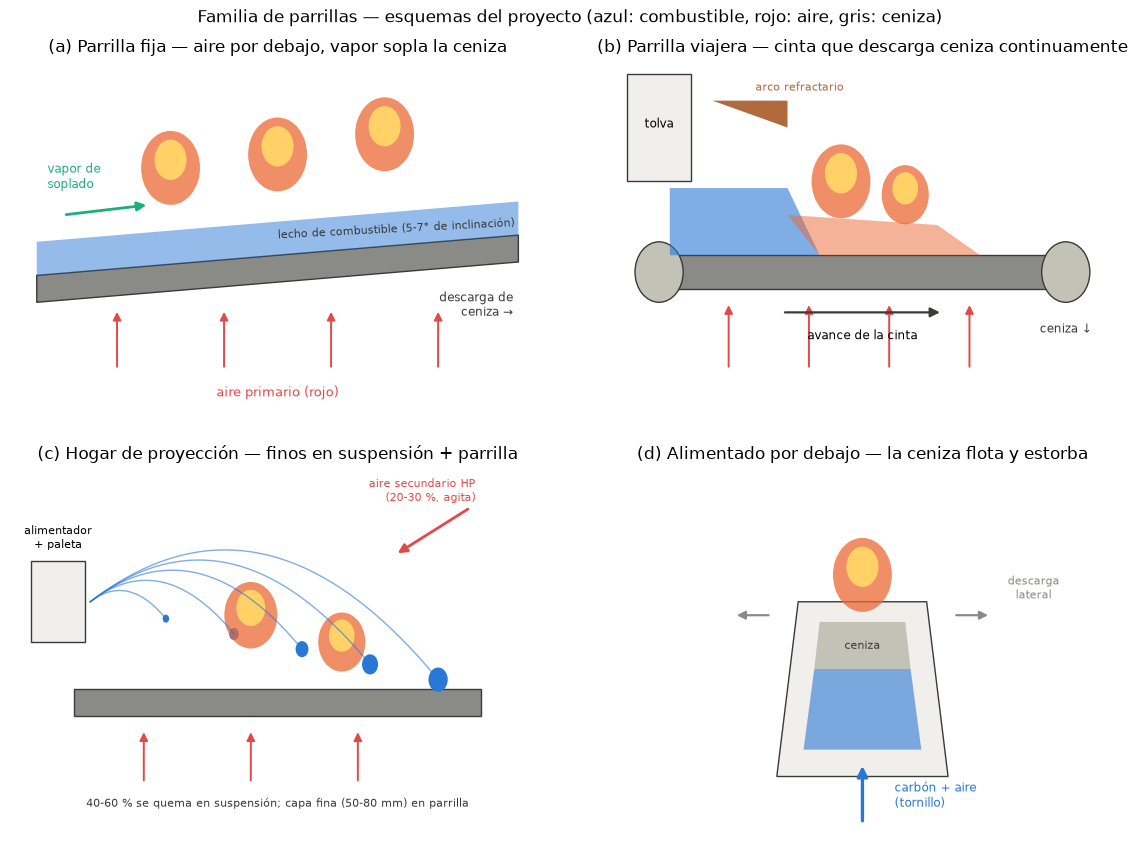

In [8]:
# Diagrama propio — familia de parrillas (reemplaza 5 escaneos del original)
fig, axs = plt.subplots(2, 2, figsize=(11.5, 8.6))
def flechas_aire(ax, xs, y0, y1):
    for x in xs:
        ax.add_patch(FancyArrowPatch((x, y0), (x, y1), arrowstyle="-|>",
                                     mutation_scale=12, color=COL["O2"], lw=1.4))
def llama(ax, x, y, s=1.0):
    ax.add_patch(Wedge((x, y), 0.55 * s, 0, 360, fc=COL["llama"], ec="none", alpha=0.75))
    ax.add_patch(Wedge((x, y + 0.12 * s), 0.3 * s, 0, 360, fc="#ffd166", ec="none"))

ax = axs[0, 0]  # --- parrilla fija ---
ax.set_title("(a) Parrilla fija — aire por debajo, vapor sopla la ceniza")
ax.add_patch(Polygon([(0.5, 2.0), (9.5, 2.6), (9.5, 2.2), (0.5, 1.6)], fc="#8a8a86", ec=COL["tinta"]))
ax.add_patch(Polygon([(0.5, 2.0), (9.5, 2.6), (9.5, 3.1), (0.5, 2.5)], fc=COL["fuel"], alpha=0.5, ec="none"))
llama(ax, 3, 3.6); llama(ax, 5, 3.8); llama(ax, 7, 4.1)
flechas_aire(ax, [2, 4, 6, 8], 0.6, 1.5)
ax.add_patch(FancyArrowPatch((1.0, 2.9), (2.6, 3.05), arrowstyle="-|>", mutation_scale=13,
                             color=COL["H2O"], lw=2))
ax.text(0.7, 3.3, "vapor de\nsoplado", fontsize=8.5, color=COL["H2O"])
ax.text(9.4, 1.4, "descarga de\nceniza →", ha="right", fontsize=8.5, color=COL["tinta"])
ax.text(5, 0.2, "aire primario (rojo)", ha="center", fontsize=9, color=COL["O2"])
ax.text(5, 2.55, "lecho de combustible (5-7° de inclinación)", fontsize=8, color=COL["tinta"], rotation=3)

ax = axs[0, 1]  # --- parrilla viajera ---
ax.set_title("(b) Parrilla viajera — cinta que descarga ceniza continuamente")
ax.add_patch(Rectangle((1.2, 1.8), 7.6, 0.5, fc="#8a8a86", ec=COL["tinta"]))
for cx in [1.2, 8.8]:
    ax.add_patch(Circle((cx, 2.05), 0.45, fc="#c3c2b7", ec=COL["tinta"]))
ax.add_patch(Polygon([(1.4, 2.3), (4.2, 2.3), (3.6, 3.3), (1.4, 3.3)], fc=COL["fuel"], alpha=0.6, ec="none"))
ax.add_patch(Polygon([(4.2, 2.3), (7.2, 2.3), (6.4, 2.75), (3.6, 2.9)], fc=COL["llama"], alpha=0.5, ec="none"))
ax.add_patch(Rectangle((0.6, 3.4), 1.2, 1.6, fc="#f0efec", ec=COL["tinta"]))  # tolva
ax.text(1.2, 4.2, "tolva", ha="center", fontsize=8.5)
llama(ax, 4.6, 3.4); llama(ax, 5.8, 3.2, 0.8)
flechas_aire(ax, [2.5, 4, 5.5, 7], 0.6, 1.6)
ax.add_patch(FancyArrowPatch((3.5, 1.45), (6.5, 1.45), arrowstyle="-|>", mutation_scale=14,
                             color=COL["tinta"], lw=1.6))
ax.text(5, 1.05, "avance de la cinta", ha="center", fontsize=8.5)
ax.text(8.8, 1.15, "ceniza ↓", ha="center", fontsize=8.5, color=COL["tinta"])
ax.add_patch(Polygon([(2.2, 4.6), (3.6, 4.2), (3.6, 4.6)], fc="#b06a3b", ec="none"))
ax.text(3.0, 4.75, "arco refractario", fontsize=8, color="#b06a3b")

ax = axs[1, 0]  # --- hogar de proyección ---
ax.set_title("(c) Hogar de proyección — finos en suspensión + parrilla")
ax.add_patch(Rectangle((1.2, 1.5), 7.6, 0.4, fc="#8a8a86", ec=COL["tinta"]))
ax.add_patch(Rectangle((0.4, 2.6), 1.0, 1.2, fc="#f0efec", ec=COL["tinta"]))
ax.text(0.9, 4.0, "alimentador\n+ paleta", ha="center", fontsize=8)
th = np.linspace(0.25, 1.15, 5)
for i_t, tt in enumerate(th):  # trayectorias parabólicas: grande → lejos
    xs = np.linspace(1.5, 1.5 + 6.5 * tt / th[-1], 40)
    ys = 3.2 + (xs - 1.5) * np.tan(0.55) - 0.14 * (xs - 1.5) ** 2 / tt
    ax.plot(xs, ys, color=COL["fuel"], lw=1.0, alpha=0.6)
    ax.add_patch(Circle((xs[-1], max(ys[-1], 2.0)), 0.06 + 0.03 * i_t, fc=COL["fuel"], ec="none"))
llama(ax, 4.5, 3.0, 0.9); llama(ax, 6.2, 2.6, 0.8)
flechas_aire(ax, [2.5, 4.5, 6.5], 0.5, 1.3)
ax.add_patch(FancyArrowPatch((8.6, 4.6), (7.2, 3.9), arrowstyle="-|>", mutation_scale=13,
                             color=COL["O2"], lw=2))
ax.text(8.7, 4.7, "aire secundario HP\n(20-30 %, agita)", fontsize=8, color=COL["O2"], ha="right")
ax.text(5, 0.15, "40-60 % se quema en suspensión; capa fina (50-80 mm) en parrilla",
        ha="center", fontsize=8, color=COL["tinta"])

ax = axs[1, 1]  # --- alimentado por debajo ---
ax.set_title("(d) Alimentado por debajo — la ceniza flota y estorba")
ax.add_patch(Polygon([(3.4, 0.6), (6.6, 0.6), (6.2, 3.2), (3.8, 3.2)], fc="#f0efec", ec=COL["tinta"]))
ax.add_patch(Polygon([(3.9, 1.0), (6.1, 1.0), (5.9, 2.2), (4.1, 2.2)], fc=COL["fuel"], alpha=0.6, ec="none"))
ax.add_patch(Polygon([(4.1, 2.2), (5.9, 2.2), (5.8, 2.9), (4.2, 2.9)], fc=COL["ceniza"], ec="none"))
llama(ax, 5.0, 3.6, 1.0)
ax.add_patch(FancyArrowPatch((5.0, -0.1), (5.0, 0.8), arrowstyle="-|>", mutation_scale=15,
                             color=COL["fuel"], lw=2.4))
ax.text(5.6, 0.15, "carbón + aire\n(tornillo)", fontsize=8.5, color=COL["fuel"])
for sx in (3.3, 6.7):
    ax.add_patch(FancyArrowPatch((sx, 3.0), (sx + (0.7 if sx > 5 else -0.7), 3.0),
                                 arrowstyle="-|>", mutation_scale=12, color=COL["N2"], lw=1.6))
ax.text(5.0, 2.5, "ceniza", ha="center", fontsize=8, color=COL["tinta"])
ax.text(8.2, 3.25, "descarga\nlateral", fontsize=8, color=COL["N2"], ha="center")
for ax in axs.ravel():
    ax.set_xlim(0, 10); ax.set_ylim(-0.3, 5.2); ax.axis("off")
plt.suptitle("Familia de parrillas — esquemas del proyecto (azul: combustible, rojo: aire, gris: ceniza)",
             fontsize=12)
plt.tight_layout(); plt.show()

### 6.5 Combustores de lecho fluidizado

> **¿Qué obstáculo ataca?** ¡Los cuatro a la vez! El aire **sostiene** las partículas (contacto máximo), la agitación **mezcla** y **desgasta la ceniza** por atrición, y la gran masa térmica del lecho de arena estabiliza la temperatura.

#### Etapas de Fluidización

**Lecho estático**: Cuando se fuerza el paso de aire a través de un lecho cerrado de sólidos esparcidos sobre una placa inferior, el aire fluye a través de los espacios vacíos del lecho sin perturbarlo. A medida que aumenta la cantidad de aire, la velocidad y la caída de presión (Δp) a través del lecho aumentan de manera más o menos lineal hasta que el lecho comienza a expandirse y levantarse. Esto se conoce como lecho estático.

**Fluidización**: En algún punto, llamado punto de fluidización mínimo, el lecho comienza a levantarse de la placa inferior. Para un lecho de partículas de carbón de $<$10 mm, el punto de fluidización está a $\approx$ 1 m/s de velocidad del lecho. A este punto se le llama inicio de la fluidización.

La **velocidad del lecho** es la velocidad del aire o gas que abandona el lecho, expresada en volumen de fluido por área del lecho.

**Lecho burbujeante**: A medida que el flujo aumenta aún más, se forman burbujas de aire y la altura del lecho aumenta. Las partículas en el lecho comienzan a girar dentro del lecho expandido. El lecho es plano y se agita vigorosamente. A esto se le llama lecho burbujeante porque el proceso se asemeja al burbujeo del agua caliente.

**Lecho circulante**: Con un mayor aumento del flujo de aire, el lecho se expande para llenar la cámara superior y forma una nube de partículas. La nube es densa en la parte inferior y menos densa en la parte superior, con algunas partículas que efectivamente salen de la cámara mientras la mayoría fluye hacia abajo a lo largo de las paredes de la cámara. Las partículas elutriadas pueden regresar al lecho para establecer una circulación de partículas del lecho. Esto ocurre a velocidades del lecho $\geq$4 m/s cuando el diámetro medio de las partículas se mantiene bajo en 0.5–1 mm, y se denomina lecho de circulación completa o lecho de fluidización rápida.

**Lecho expandido o turbulento**: Esta es una etapa de la fluidización que se encuentra entre los lechos burbujeante y circulante.

**Arrastre o transporte por arrastre**: A velocidades >~7 m/s, el fenómeno entra en un régimen de transporte cuando las partículas simplemente abandonan la cámara sin regresar al lecho a lo largo de las paredes, lo que marca el final del proceso de fluidización. Esto se denomina inicio del arrastre o flujo de transporte.

La física del punto de fluidización es un balance de fuerzas: la fluidización comienza cuando la caída de presión del aire (ecuación de **Ergun**) iguala el **peso del lecho** por unidad de área:

$$\frac{\Delta p}{L} = \underbrace{150\,\frac{\mu\,(1-\varepsilon)^2}{\varepsilon^3 d_p^2}\,u}_{\text{viscoso}} + \underbrace{1.75\,\frac{\rho_g (1-\varepsilon)}{\varepsilon^3 d_p}\,u^2}_{\text{inercial}} \;\;\xrightarrow{\;u = u_{mf}\;}\;\; \Delta p = (1-\varepsilon)(\rho_p - \rho_g)\,g\,L$$

donde $u$ [m/s] es la velocidad superficial, $d_p$ [m] el diámetro de partícula, $\varepsilon$ la fracción de vacío y $\rho_p, \rho_g$ [kg/m³] las densidades. El widget regenera (¡viva!) la clásica curva Δp–u del original.

In [ ]:
# WIDGET 5 — regímenes de fluidización: curva Δp-u viva + dinámica del lecho
rng5 = np.random.default_rng(5)
P_LECHO = rng5.uniform(0.05, 0.95, (240, 2))

def u_minima_fluidizacion(dp, rho_p, eps=0.45, L=0.5, mu=4.0e-5, rho_g=0.4):
    # aire caliente del hogar (~600 °C): μ≈4e-5 Pa·s, ρ≈0.4 kg/m³
    dp_pa = (1 - eps) * (rho_p - rho_g) * 9.81 * L
    a = 1.75 * rho_g * (1 - eps) * L / (eps**3 * dp)
    b = 150 * mu * (1 - eps)**2 * L / (eps**3 * dp**2)
    return (-b + np.sqrt(b**2 + 4 * a * dp_pa)) / (2 * a), dp_pa, a, b

def u_terminal(dp, rho_p, mu=4.0e-5, rho_g=0.4):
    def resid(u):
        Re = max(rho_g * u * dp / mu, 1e-9)
        Cd = 24 / Re * (1 + 0.15 * Re**0.687) + 0.42 / (1 + 42500 / Re**1.16)
        return Cd * 0.5 * rho_g * u**2 * np.pi * dp**2 / 4 - (rho_p - rho_g) * 9.81 * np.pi * dp**3 / 6
    return brentq(resid, 1e-4, 400.0)

def fluidizacion(dp_mm=1.0, rho_p=1300.0, u=2.0):
    dp = dp_mm / 1000
    umf, dp_pa, a, b = u_minima_fluidizacion(dp, rho_p)
    ut = u_terminal(dp, rho_p)
    us = np.linspace(0.01, max(1.3 * ut, 3 * umf, u * 1.2), 400)
    ergun = a * us**2 + b * us
    curva = np.where(us < umf, ergun, dp_pa)
    if u < umf: regimen = "lecho estático"
    elif u < 2.5 * umf: regimen = "burbujeante"
    elif u < ut: regimen = "turbulento / circulante"
    else: regimen = "transporte (arrastre)"
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.5, 5.1),
                                   gridspec_kw={"width_ratios": [1.4, 1]})
    ax0.plot(us, curva / 1000, color=COL["fuel"], lw=2.4)
    ax0.plot(us[us < umf], (a * us[us < umf]**2 + b * us[us < umf]) / 1000, lw=0)  # (rama Ergun ya dibujada)
    ax0.axhline(dp_pa / 1000, color=COL["N2"], lw=1, ls=":")
    ax0.text(us[-1] * 0.99, dp_pa / 1000 * 1.03, "peso del lecho / área", ha="right",
             fontsize = 8.5, color=COL["N2"])
    for uu, nom in [(umf, "u$_{mf}$"), (ut, "u$_t$ (arrastre)")]:
        if uu < us[-1]:
            ax0.axvline(uu, color=COL["tinta"], lw=1, ls="--", alpha=0.6)
            ax0.text(uu, ax0.get_ylim()[1] * 0.02, f" {nom} = {uu:.2f} m/s", fontsize=9,
                     color=COL["tinta"], rotation=90, va="bottom")
    y_u = np.interp(u, us, curva) / 1000
    ax0.plot(u, y_u, "o", ms=10, color=COL["O2"], mec="white", mew=1.5, zorder=5)
    ax0.annotate(f"u = {u:.2f} m/s\n{regimen}", xy=(u, y_u), xytext=(u * 1.05, y_u * 0.55),
                 fontsize=10, color=COL["tinta"],
                 arrowprops=dict(arrowstyle="->", color=COL["tinta"], lw=1))
    ax0.set_xlabel("velocidad superficial u [m/s]"); ax0.set_ylabel("Δp del lecho [kPa]")
    ax0.set_title(f"Curva Δp–u (Ergun→peso) — d$_p$ = {dp_mm:g} mm, ρ$_p$ = {rho_p:.0f} kg/m³")
    ax0.grid(alpha=0.25); ax0.spines[["top", "right"]].set_visible(False)
    # --- el lecho como conjunto de partículas ---
    if regimen == "lecho estático":
        pos = P_LECHO * [1.0, 0.32]
    elif regimen == "burbujeante":
        pos = P_LECHO * [1.0, 0.45] + rng5.normal(0, 0.012, P_LECHO.shape)
        for bx, by, br in [(0.3, 0.18, 0.06), (0.65, 0.3, 0.08), (0.5, 0.1, 0.045)]:
            ax1.add_patch(Circle((bx, by), br, fc="white", ec=COL["N2"], lw=0.8, zorder=3))
    elif regimen.startswith("turb"):
        y_raw = P_LECHO[:, 1] ** 1.6
        pos = np.c_[P_LECHO[:, 0], y_raw * 0.95]
        for wx in (0.03, 0.97):
            ax1.add_patch(FancyArrowPatch((wx, 0.75), (wx, 0.45), arrowstyle="-|>",
                                          mutation_scale=11, color=COL["tinta"], lw=1.4, zorder=4))
    else:
        pos = np.c_[P_LECHO[:120, 0], P_LECHO[:120, 1] * 0.98]
        for fx in (0.35, 0.65):
            ax1.add_patch(FancyArrowPatch((fx, 0.86), (fx, 1.03), arrowstyle="-|>",
                                          mutation_scale=13, color=COL["O2"], lw=1.8, zorder=4))
    ax1.scatter(pos[:, 0], np.clip(pos[:, 1], 0.01, 1.03), s=9, color=COL["tinta"], zorder=2)
    for x in np.linspace(0.12, 0.88, 5):
        ax1.add_patch(FancyArrowPatch((x, -0.14), (x, -0.02), arrowstyle="-|>",
                                      mutation_scale=10, color=COL["O2"], lw=1.2))
    ax1.add_patch(Rectangle((0, -0.015), 1, 0.015, fc=COL["N2"], ec="none"))
    ax1.set_title(f"régimen: {regimen}")
    ax1.set_xlim(-0.05, 1.05); ax1.set_ylim(-0.16, 1.1); ax1.axis("off")
    plt.tight_layout(); plt.show()

interact(fluidizacion,
         dp_mm=FloatSlider(1.0, min=0.1, max=10.0, step=0.1, description="d_p [mm]"),
         rho_p=FloatSlider(1300, min=600, max=2600, step=50, description="ρ_p [kg/m³]"),
         u=FloatSlider(2.0, min=0.05, max=12.0, step=0.05, description="u [m/s]"));

interactive(children=(FloatSlider(value=1.0, description='d_p [mm]', max=10.0, min=0.1), FloatSlider(value=130…

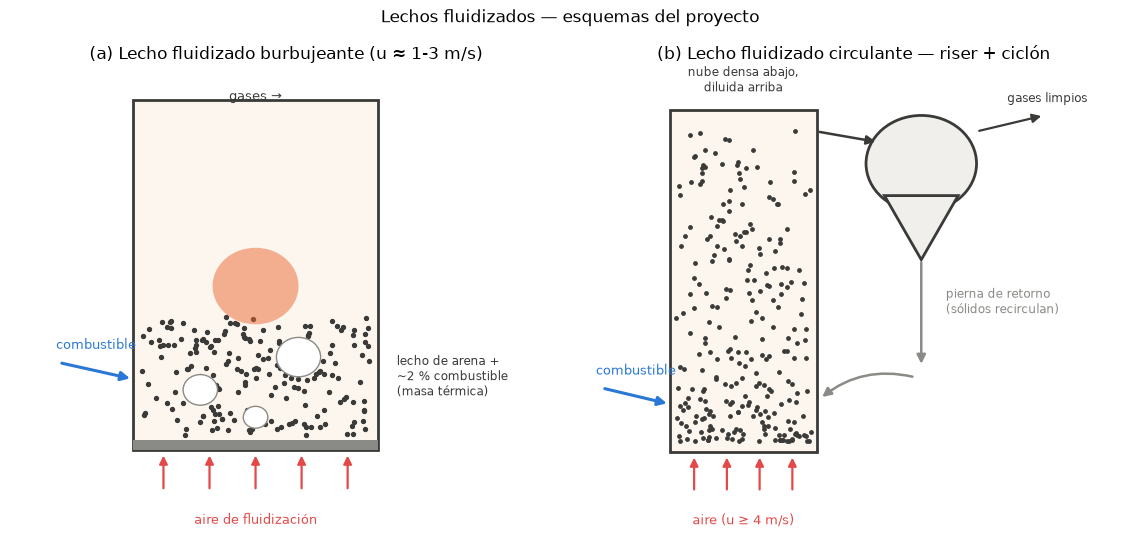

In [10]:
# Diagrama propio — lecho fluidizado burbujeante y circulante (reemplaza 2 escaneos)
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.5, 5.6))
rngd = np.random.default_rng(9)
# --- burbujeante ---
ax0.add_patch(Rectangle((2, 0.6), 4, 6.4, fc="#fdf6ee", ec=COL["tinta"], lw=2))
ax0.add_patch(Rectangle((2, 0.6), 4, 0.18, fc=COL["N2"], ec="none"))          # placa distribuidora
pb = rngd.uniform(0, 1, (200, 2)) * [3.7, 2.2] + [2.15, 0.85]
ax0.scatter(pb[:, 0], pb[:, 1], s=8, color=COL["tinta"])
for bx, by, br in [(3.1, 1.7, 0.28), (4.7, 2.3, 0.36), (4.0, 1.2, 0.2)]:
    ax0.add_patch(Circle((bx, by), br, fc="white", ec=COL["N2"], zorder=3))
llama_y = 3.6
ax0.add_patch(Wedge((4.0, llama_y), 0.7, 0, 360, fc=COL["llama"], alpha=0.5, ec="none"))
for x in np.linspace(2.5, 5.5, 5):
    ax0.add_patch(FancyArrowPatch((x, -0.15), (x, 0.55), arrowstyle="-|>",
                                  mutation_scale=12, color=COL["O2"], lw=1.6))
ax0.add_patch(FancyArrowPatch((0.8, 2.2), (2.0, 1.9), arrowstyle="-|>", mutation_scale=13,
                              color=COL["fuel"], lw=2.2))
ax0.text(0.75, 2.45, "combustible", fontsize=9, color=COL["fuel"])
ax0.text(4, 7.0, "gases →", fontsize=9, color=COL["tinta"], ha="center")
ax0.text(4, -0.75, "aire de fluidización", fontsize=9, color=COL["O2"], ha="center")
ax0.text(6.3, 1.6, "lecho de arena +\n~2 % combustible\n(masa térmica)", fontsize=8.5, color=COL["tinta"])
ax0.set_title("(a) Lecho fluidizado burbujeante (u ≈ 1-3 m/s)")
ax0.set_xlim(0, 9); ax0.set_ylim(-1.1, 7.6); ax0.axis("off")
# --- circulante ---
ax1.add_patch(Rectangle((1.5, 0.6), 2.4, 6.4, fc="#fdf6ee", ec=COL["tinta"], lw=2))  # riser
pc = rngd.uniform(0, 1, (260, 2))
dens = pc[:, 1] ** 1.8
ax1.scatter(1.6 + pc[:, 0] * 2.2, 0.8 + dens * 5.9, s=6, color=COL["tinta"])
ax1.add_patch(Circle((5.6, 6.0), 0.9, fc="#f0efec", ec=COL["tinta"], lw=2))          # ciclón
ax1.add_patch(Polygon([(5.0, 5.4), (6.2, 5.4), (5.6, 4.2)], fc="#f0efec", ec=COL["tinta"], lw=2))
ax1.add_patch(FancyArrowPatch((3.9, 6.6), (4.9, 6.4), arrowstyle="-|>", mutation_scale=13,
                              color=COL["tinta"], lw=1.8))
ax1.add_patch(FancyArrowPatch((5.6, 4.2), (5.6, 2.2), arrowstyle="-|>", mutation_scale=13,
                              color=COL["N2"], lw=1.8))
ax1.add_patch(FancyArrowPatch((5.5, 2.0), (3.95, 1.6), arrowstyle="-|>", mutation_scale=13,
                              color=COL["N2"], lw=1.8, connectionstyle="arc3,rad=0.25"))
ax1.text(6.0, 3.2, "pierna de retorno\n(sólidos recirculan)", fontsize=8.5, color=COL["N2"])
ax1.add_patch(FancyArrowPatch((6.5, 6.6), (7.6, 6.9), arrowstyle="-|>", mutation_scale=13,
                              color=COL["tinta"], lw=1.6))
ax1.text(7.0, 7.15, "gases limpios", fontsize=8.5, color=COL["tinta"])
for x in np.linspace(1.9, 3.5, 4):
    ax1.add_patch(FancyArrowPatch((x, -0.15), (x, 0.55), arrowstyle="-|>",
                                  mutation_scale=12, color=COL["O2"], lw=1.6))
ax1.add_patch(FancyArrowPatch((0.4, 1.8), (1.5, 1.5), arrowstyle="-|>", mutation_scale=13,
                              color=COL["fuel"], lw=2.2))
ax1.text(0.3, 2.05, "combustible", fontsize=9, color=COL["fuel"])
ax1.text(2.7, -0.75, "aire (u ≥ 4 m/s)", fontsize=9, color=COL["O2"], ha="center")
ax1.text(2.7, 7.35, "nube densa abajo,\ndiluida arriba", fontsize=8.5, ha="center", color=COL["tinta"])
ax1.set_title("(b) Lecho fluidizado circulante — riser + ciclón")
ax1.set_xlim(0, 9); ax1.set_ylim(-1.1, 7.8); ax1.axis("off")
plt.suptitle("Lechos fluidizados — esquemas del proyecto", fontsize=12)
plt.tight_layout(); plt.show()

### 6.6 Combustores en hogar ciclónico

> **¿Qué obstáculo ataca?** La **mezcla** (obstáculo 4): el aire secundario tangencial impone un giro violento que multiplica los encuentros partícula-O₂ y alarga el **tiempo de residencia** en espiral.

En un hogar ciclónico, la mezcla de partículas finas y aire primario entra al horno a través de una tubería central, mientras que el aire secundario (SA) desde la caja de aire ingresa tangencialmente para dar un giro a los gases. El aire primario y el aire secundario están casi en ángulo recto entre sí para que las partículas de combustible se limpien de manera efectiva. Las llamas son cortas, densas y turbulentas. La formación de NOx (óxidos de nitrógeno) es alta *(consecuencia directa de la alta temperatura local — el mismo Arrhenius del NOx que veremos en §8.3)*, y los diseños modernos adoptan la división del SA para prolongar la combustión. Además, el reparto de aire alrededor de la zona principal de combustión produce una combustión escalonada, lo que resulta en menores niveles de NOx. Una caja de aire compartimentada con medición independiente del flujo de aire es una de las primeras formas de reducir el NOx.

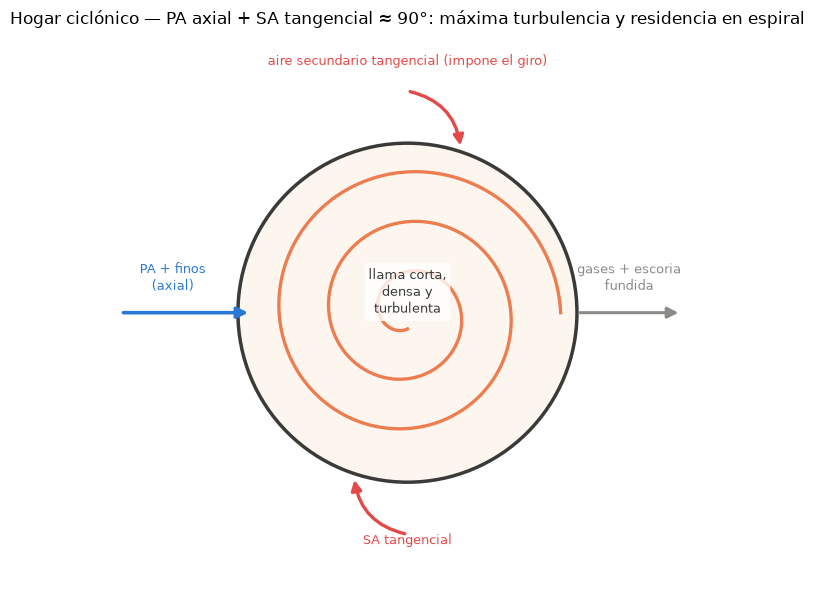

In [11]:
# Diagrama propio — hogar ciclónico (reemplaza 1 escaneo)
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.add_patch(Circle((5, 3.2), 2.6, fc="#fdf6ee", ec=COL["tinta"], lw=2.5))
th = np.linspace(0, 5.5 * np.pi, 500)
r_esp = 0.25 + 2.1 * th / th[-1]
ax.plot(5 + r_esp[::-1] * np.cos(th), 3.2 + r_esp[::-1] * np.sin(th), color=COL["llama"], lw=2.4, alpha=0.85)
ax.add_patch(FancyArrowPatch((0.6, 3.2), (2.6, 3.2), arrowstyle="-|>", mutation_scale=16,
                             color=COL["fuel"], lw=2.6))
ax.text(1.4, 3.55, "PA + finos\n(axial)", fontsize=9.5, color=COL["fuel"], ha="center")
for ang, dxy in [(90, (0, -1)), (270, (0, 1))]:
    x0 = 5 + 3.4 * np.cos(np.radians(ang)); y0 = 3.2 + 3.4 * np.sin(np.radians(ang))
    x1 = 5 + 2.65 * np.cos(np.radians(ang - 18)); y1 = 3.2 + 2.65 * np.sin(np.radians(ang - 18))
    ax.add_patch(FancyArrowPatch((x0, y0), (x1, y1), arrowstyle="-|>", mutation_scale=15,
                                 color=COL["O2"], lw=2.4, connectionstyle="arc3,rad=-0.35"))
ax.text(5, 7.0, "aire secundario tangencial (impone el giro)", fontsize=9.5, color=COL["O2"], ha="center")
ax.text(5, -0.35, "SA tangencial", fontsize=9.5, color=COL["O2"], ha="center")
ax.add_patch(FancyArrowPatch((7.6, 3.2), (9.2, 3.2), arrowstyle="-|>", mutation_scale=16,
                             color=COL["N2"], lw=2.2))
ax.text(8.4, 3.55, "gases + escoria\nfundida", fontsize=9, color=COL["N2"], ha="center")
ax.text(5, 3.2, "llama corta,\ndensa y\nturbulenta", fontsize=9.5, ha="center", color=COL["tinta"],
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.8))
ax.set_xlim(0, 10); ax.set_ylim(-0.9, 7.5); ax.set_aspect("equal"); ax.axis("off")
ax.set_title("Hogar ciclónico — PA axial + SA tangencial ≈ 90°: máxima turbulencia y residencia en espiral")
plt.tight_layout(); plt.show()

## 7. Tecnologías de Combustión de Líquidos

Los combustibles líquidos son aquellos que están en estado líquido a temperatura ambiente: gasolina y diésel (destilados del petróleo — su origen y refinación se estudiaron en la **Lección 4** §5), y los biocombustibles (bioetanol por fermentación de azúcares; biodiésel de aceites vegetales o grasas animales). La composición elemental típica del petróleo — el dato que alimenta los balances de la Lección 7:

| Componente | Contenido (%) |
|------------|---------------|
| Carbono    | 84 – 87       |
| Hidrógeno  | 11 – 16       |
| Oxígeno    | 0 – 7         |
| Nitrógeno  | 0 – 7         |
| Azufre     | 0 – 4         |

> **¿Qué obstáculo ataca el atomizador?** El 1 (área de contacto): una gota no arde como líquido — primero **se evapora** desde su superficie y el vapor es lo que quema. La ley $d^2$ de la §2 manda: atomizar el aceite en gotas de ~50-200 μm multiplica el área por miles y reduce el tiempo de evaporación de minutos a milisegundos.

### 7.1 Atomizador de tipo mecánico

El atomizador mecánico es uno en el que la presión del propio combustible atomiza el combustible. También se le llama atomizador de chorro a presión. Existen varios tipos de atomizadores mecánicos. El más ampliamente utilizado se muestra en la figura. Hay tres partes principales del quemador:

- Atomizador
- Generador de giro (*swirler*)
- Distribuidor de flujo

Estos están dispuestos a lo largo del eje del quemador. El aceite fluye primero a través de un conjunto de pequeños orificios del distribuidor de flujo, luego fluye a través de las ranuras tangenciales del *swirler*, que hacen que el aceite gire. Luego, el aceite entra en la cámara de remolino de la boquilla atomizadora. Desde aquí, el aceite gira rápidamente en la cámara de remolino y sale a chorros desde la boquilla atomizadora, formando gotas. Dado que el diseño mecánico del paso del flujo hace que el aceite se atomice, a estos tipos de atomizadores se les llama atomizadores mecánicos.

### 7.2 Atomizador asistido por vapor (tipo Y)

En el atomizador tipo Y un chorro de **vapor** (o aire comprimido) se encuentra con el chorro de aceite en un orificio de mezcla: la energía cinética del vapor desgarra el líquido en gotas mucho más finas que la sola presión del aceite. Las ecuaciones de diseño (Basu et al., 2000):

__Número de orificios $n$__: Debe estar entre 5 y 30 por atomizador. Un mayor número de orificios de diámetro pequeño solo se puede utilizar si el caudal de aceite es constante.

__Diámetro de los orificios de aceite $d_1$__: El aceite a presión $P_0$ entra al orificio de mezcla a través de los orificios de aceite. Para el número seleccionado de orificios, $n$, el diámetro del orificio, $d_1$, se puede calcular a partir del área total de sección transversal de los orificios de aceite, $F_1$. El caudal de aceite requerido, $G$, será proporcional a la raíz cuadrada de la caída de presión a través del orificio de aceite y su densidad:

$$G = 3600\, \mu\, F_1 \sqrt{2\, \rho\, \Delta P}$$

donde $G$ [kg/h] es el caudal de aceite del atomizador, $\mu \approx 0.7$ el coeficiente de flujo, $F_1$ [m²] el área total de los orificios de aceite, $\rho$ [kg/m³] la densidad del aceite y $\Delta P = P_0 - P_3$ [Pa] la diferencia entre la presión del aceite y la del punto de mezcla.

__Diámetro de los orificios de vapor o aire, $d_2$__: se basa en la tasa de consumo de vapor (o aire), $m_2$, que debe estar en el rango de 0.015–0.02 kg de vapor por kg de aceite para garantizar una adecuada calidad de atomización. De la mecánica de fluidos, la tasa de consumo es proporcional a la raíz cuadrada de su presión en la entrada:

$$m_2 = 3600\, \mu\, F_2\, \psi \sqrt{P_2\, \rho_s}$$

donde $F_2$ [m²] es el área total de los orificios de vapor, $\psi$ = 2.09 para vapor sobrecalentado (1.99 saturado, 2.14 aire comprimido), $P_2$ [Pa] la presión absoluta del medio atomizador y $\rho_s$ [kg/m³] su densidad.

Debido a la resistencia de los orificios, la presión en la cámara de mezcla $P_3$ es una fracción de la presión aguas arriba: $P_3 = \beta P_2$, con $\beta \approx 0.94$ para presión de aceite mayor que la de vapor.

Después de que el medio atomizador entra al orificio de mezcla, es perturbado por el aceite que fluye desde los orificios de aceite, por lo que es difícil conocer con precisión el coeficiente de flujo; depende de la relación de áreas y de la velocidad de salida del aceite. Para una primera aproximación se toma de la correlación lineal de datos experimentales. La relación de diámetros se toma en el rango $d_2/d_1 = 1.0\text{–}1.4$ para una primera estimación.

__Diámetro del orificio de mezcla, $d_3$__: el área del orificio de mezcla está cerca de la suma de las áreas de vapor y aceite, de donde $d_3/d_2 = 1.4\text{–}1.8$.

__Longitudes__: para permitir una buena mezcla vapor-aceite y transferencia completa de la energía del vapor al aceite:

$$\frac{l_1}{d_3} = 0.7 \qquad\qquad \frac{l_3}{d_3} = 4.0\text{–}5.0$$

__Ángulo de atomización $\theta_a$__: el rango preferido es 70–90°; el ángulo real puede ser 15–25° mayor que el de diseño.

__Diámetro de la línea central de orificios de vapor__ (espaciado mínimo de 1 mm entre orificios adyacentes en la circunferencia):

$$D_{air} = \frac{n\,(d_2 + 1)}{\pi} \qquad\qquad D_{mix} = D_{air} + 2\,(l_1 + l_2 + l_3)\sin\!\left(\frac{\theta_a}{2}\right)$$

con $l_2/d_2 = 2\text{–}10$ según conveniencia de fabricación.

__Diámetro medio ponderado de las gotas__ (correlación empírica; unidades mixtas de los datos originales):

$$d_{drop} = \frac{200\; \nu_{oil}^{0.5}\; m_{oil}^{0.1} \left(1 + \frac{1}{q}\right)^{0.5} d_3^{0.1}\; \sigma_{oil}^{0.2}}{\rho_{steam}^{0.3}\; w_{cr}}$$

donde $\nu_{oil}$ [cSt] es la viscosidad del aceite, $m_{oil}$ [g/s] el flujo de aceite por orificio, $q$ [g vapor/kg aceite] la tasa de consumo de vapor, $d_3$ [cm], $\sigma_{oil}$ [dyn/cm] la tensión superficial, $\rho_{steam}$ [g/cm³] la densidad del vapor en el orificio de mezcla, y $w_{cr} = k\sqrt{P_{steam}\,\nu_{steam}}$ [m/s] la velocidad relativa aceite-vapor ($k$ = 3.33 vapor sobrecalentado, 3.22 saturado, 3.38 aire; $\nu_{steam}$ [m³/kg] volumen específico).

*(Nota de edición: en la versión anterior de esta lección la correlación aparecía con el factor $(1+\tfrac{1}{1})^{0.5}$ y sin definir $w_{cr}$ — se restauró $(1+\tfrac{1}{q})^{0.5}$ y la expresión de $w_{cr}$ a partir de la lista de variables original y del análisis dimensional.)*

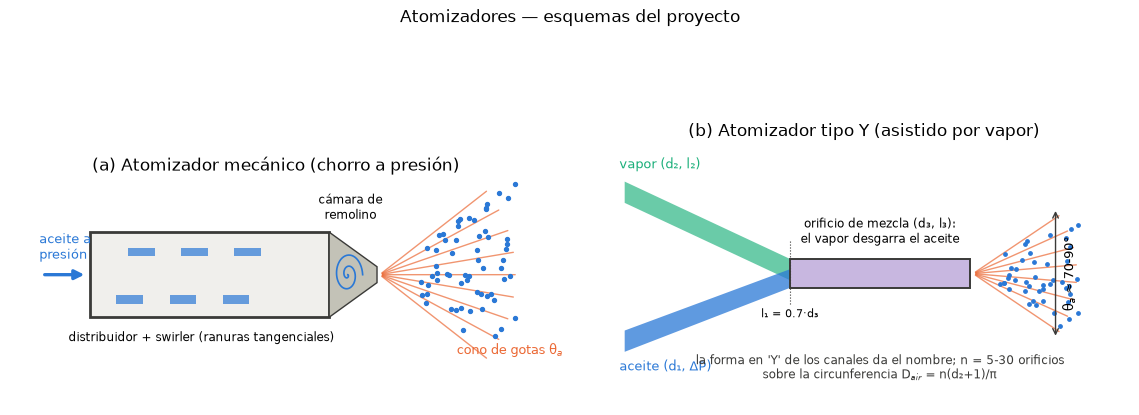

In [12]:
# Diagrama propio — atomizador mecánico y atomizador Y (reemplaza 2 escaneos)
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.5, 5.2))
# --- mecánico (chorro a presión con swirl) ---
ax0.add_patch(Rectangle((0.5, 2.2), 4.5, 1.6, fc="#f0efec", ec=COL["tinta"], lw=2))
for xr in np.linspace(1.0, 3.0, 3):                     # ranuras tangenciales del swirler
    ax0.add_patch(Rectangle((xr, 2.45), 0.5, 0.16, fc=COL["fuel"], ec="none", alpha=0.7))
    ax0.add_patch(Rectangle((xr + 0.22, 3.35), 0.5, 0.16, fc=COL["fuel"], ec="none", alpha=0.7))
ax0.add_patch(Polygon([(5.0, 2.2), (5.9, 2.85), (5.9, 3.15), (5.0, 3.8)], fc="#c3c2b7", ec=COL["tinta"]))
th_sw = np.linspace(0, 4 * np.pi, 200)                  # remolino en la cámara
ax0.plot(5.35 + 0.28 * (1 - th_sw / th_sw[-1]) * np.cos(th_sw),
         3.0 + 0.42 * (1 - th_sw / th_sw[-1]) * np.sin(th_sw), color=COL["fuel"], lw=1.2)
for ang in np.linspace(-38, 38, 9):                     # cono de gotas
    a = np.radians(ang)
    ax0.add_patch(FancyArrowPatch((5.95, 3.0), (5.95 + 2.6 * np.cos(a), 3.0 + 2.6 * np.sin(a)),
                                  arrowstyle="-", color=COL["llama"], lw=1.0, alpha=0.7))
gx = 5.95 + np.random.default_rng(2).uniform(0.7, 2.6, 60)
gy = 3.0 + (gx - 5.95) * np.random.default_rng(4).uniform(-0.72, 0.72, 60)
ax0.scatter(gx, gy, s=8, color=COL["fuel"])
ax0.add_patch(FancyArrowPatch((-0.4, 3.0), (0.45, 3.0), arrowstyle="-|>", mutation_scale=14,
                              color=COL["fuel"], lw=2.4))
ax0.text(-0.45, 3.3, "aceite a\npresión", fontsize=9, color=COL["fuel"])
ax0.text(2.6, 1.75, "distribuidor + swirler (ranuras tangenciales)", fontsize=8.5, ha="center")
ax0.text(5.4, 4.05, "cámara de\nremolino", fontsize=8.5, ha="center")
ax0.text(7.4, 1.5, "cono de gotas θ$_a$", fontsize=9, color=COL["llama"])
ax0.set_title("(a) Atomizador mecánico (chorro a presión)")
ax0.set_xlim(-1, 9); ax0.set_ylim(1.2, 4.8); ax0.set_aspect("equal"); ax0.axis("off")
# --- tipo Y ---
ax1.add_patch(Polygon([(0.5, 4.6), (3.6, 3.15), (3.6, 2.75), (0.5, 4.2)], fc=COL["H2O"], alpha=0.65, ec="none"))
ax1.text(0.4, 4.85, "vapor (d₂, l₂)", fontsize=9, color=COL["H2O"])
ax1.add_patch(Polygon([(0.5, 1.4), (3.6, 2.6), (3.6, 2.95), (0.5, 1.8)], fc=COL["fuel"], alpha=0.75, ec="none"))
ax1.text(0.4, 1.05, "aceite (d₁, ΔP)", fontsize=9, color=COL["fuel"])
ax1.add_patch(Rectangle((3.6, 2.6), 3.4, 0.55, fc="#c8b7e0", ec=COL["tinta"], lw=1.4))
ax1.text(5.3, 3.45, "orificio de mezcla (d₃, l₃):\nel vapor desgarra el aceite", fontsize=8.5, ha="center")
ax1.plot([3.6, 3.6], [2.3, 3.5], color=COL["tinta"], lw=0.8, ls=":")
ax1.text(3.6, 2.05, "l₁ = 0.7·d₃", fontsize=8, ha="center")
for ang in np.linspace(-34, 34, 8):
    a = np.radians(ang)
    ax1.add_patch(FancyArrowPatch((7.05, 2.87), (7.05 + 2.0 * np.cos(a), 2.87 + 2.0 * np.sin(a)),
                                  arrowstyle="-", color=COL["llama"], lw=1.0, alpha=0.7))
gx = 7.05 + np.random.default_rng(6).uniform(0.5, 2.0, 45)
gy = 2.87 + (gx - 7.05) * np.random.default_rng(8).uniform(-0.62, 0.62, 45)
ax1.scatter(gx, gy, s=6, color=COL["fuel"])
ax1.annotate("", xy=(8.6, 4.1), xytext=(8.6, 1.65),
             arrowprops=dict(arrowstyle="<->", color=COL["tinta"], lw=1))
ax1.text(8.75, 2.87, "θ$_a$ ≈ 70-90°", fontsize=9, rotation=90, va="center")
ax1.text(5.3, 0.9, "la forma en 'Y' de los canales da el nombre; n = 5-30 orificios\nsobre la circunferencia D$_{air}$ = n(d₂+1)/π",
         fontsize=8.5, ha="center", color=COL["tinta"])
ax1.set_title("(b) Atomizador tipo Y (asistido por vapor)")
ax1.set_xlim(0, 10); ax1.set_ylim(0.4, 5.3); ax1.set_aspect("equal"); ax1.axis("off")
plt.suptitle("Atomizadores — esquemas del proyecto", fontsize=12)
plt.tight_layout(); plt.show()

In [13]:
# WIDGET 6 — diseño del atomizador Y: del caudal a los diámetros y al tamaño de gota
def atomizador_Y(G=800.0, P0_MPa=2.0, P2_MPa=0.25, n=12, q_g_kg=20.0):
    mu_f, rho_oil = 0.7, 950.0                                   # coef. de flujo, kg/m³
    nu_oil, sigma_oil = 20.0, 28.0                               # cSt, dyn/cm (fuel oil precalentado)
    psi, beta, k_w = 2.09, 0.94, 3.33                            # vapor sobrecalentado
    P2 = P2_MPa * 1e6
    rho_s = PropsSI("D", "P", P2, "T", 520.0, "Water")           # vapor a ~250 °C
    P3 = beta * P2
    dP = P0_MPa * 1e6 - P3
    if dP <= 0:
        print("⚠ P0 debe superar β·P2 — sube la presión del aceite"); return
    F1 = G / (3600 * mu_f * np.sqrt(2 * rho_oil * dP))           # m²
    d1 = np.sqrt(4 * F1 / (n * np.pi)) * 1000                    # mm
    m2 = q_g_kg / 1000 * G                                       # kg/h de vapor
    F2 = m2 / (3600 * mu_f * psi * np.sqrt(P2 * rho_s))
    d2 = np.sqrt(4 * F2 / (n * np.pi)) * 1000
    d3 = 1.6 * d2
    l1, l2, l3 = 0.7 * d3, 5.0 * d2, 4.5 * d3
    theta = 80.0
    D_air = n * (d2 + 1.0) / np.pi
    D_mix = D_air + 2 * (l1 + l2 + l3) * np.sin(np.radians(theta / 2))
    # gota: correlación empírica (unidades mixtas) + velocidad relativa
    nu_steam = 1.0 / rho_s
    w_cr = k_w * np.sqrt(P2 / 1000 * nu_steam)     # correlación empírica: P en kPa → w_cr ~ decenas de m/s
    m_oil = G / 3.6 / n                                          # g/s por orificio
    d_drop_um = (200 * nu_oil**0.5 * m_oil**0.1 * (1 + 1000 / q_g_kg / 1000)**0.5
                 * (d3 / 10)**0.1 * sigma_oil**0.2 / ((rho_s / 1000)**0.3 * w_cr))
    tau_evap = (d_drop_um / 1000)**2 / 1.0 * 1000                # ley d² con K=1 mm²/s → ms
    fig, ax = plt.subplots(figsize=(10, 5.2))
    esc = 6.0 / max(l3, 1e-6)                                    # dibujo a escala (l3 → 6 unidades)
    y0 = 3.0
    h3 = d3 * esc / 2                                            # semialtura del orificio de mezcla
    ax.add_patch(Polygon([(0.5, y0 + 3.2), (4.0, y0 + h3 * 0.9 + 0.05),
                          (4.0, y0 + 0.1), (0.5, y0 + 2.6)], fc=COL["H2O"], alpha=0.65, ec="none"))
    ax.add_patch(Polygon([(0.5, y0 - 3.2), (4.0, y0 - h3 * 0.9 - 0.05),
                          (4.0, y0 - 0.1), (0.5, y0 - 2.6)], fc=COL["fuel"], alpha=0.75, ec="none"))
    ax.add_patch(Rectangle((4.0, y0 - h3), 6.0, 2 * h3, fc="#c8b7e0", ec=COL["tinta"], lw=1.4))
    x_f = 10.0
    for ang in np.linspace(-theta / 2, theta / 2, 9):
        a = np.radians(ang)
        ax.plot([x_f, x_f + 2.2 * np.cos(a)], [y0, y0 + 2.2 * np.sin(a)],
                color=COL["llama"], lw=0.9, alpha=0.7)
    gx = x_f + np.random.default_rng(7).uniform(0.4, 2.1, 50)
    gy = y0 + (gx - x_f) * np.random.default_rng(3).uniform(-0.7, 0.7, 50)
    ax.scatter(gx, gy, s=7, color=COL["fuel"])
    ax.text(7.0, y0 + h3 + 0.3, f"d₃ = {d3:.2f} mm | l₃ = {l3:.1f} mm (a escala)",
            ha="center", fontsize=9)
    ax.text(1.6, y0 + 3.35, f"vapor: d₂ = {d2:.2f} mm ({m2:.0f} kg/h)", fontsize=9, color=COL["H2O"])
    ax.text(1.6, y0 - 3.6, f"aceite: d₁ = {d1:.2f} mm (ΔP = {dP/1e6:.2f} MPa)", fontsize=9, color=COL["fuel"])
    ok = "✔" if 1.0 <= d2 / d1 <= 1.4 else "⚠ fuera de 1.0-1.4"
    ax.set_title(f"n = {n} orificios | d₂/d₁ = {d2/d1:.2f} {ok} | D_air = {D_air:.1f} mm, "
                 f"D_mix = {D_mix:.1f} mm\n"
                 f"gota estimada d_drop ≈ {d_drop_um:.0f} μm → τ_evap ≈ {tau_evap:.1f} ms (ley d², §2)")
    ax.set_xlim(0, 13); ax.set_ylim(-1.2, 7.5); ax.set_aspect("equal"); ax.axis("off")
    plt.tight_layout(); plt.show()

interact(atomizador_Y,
         G=FloatSlider(800, min=100, max=3000, step=50, description="G aceite [kg/h]"),
         P0_MPa=FloatSlider(2.0, min=0.8, max=5.0, step=0.1, description="P₀ aceite [MPa]"),
         P2_MPa=FloatSlider(0.25, min=0.15, max=1.2, step=0.05, description="P₂ vapor [MPa]"),
         n=IntSlider(12, min=5, max=30, description="n orificios"),
         q_g_kg=FloatSlider(20, min=10, max=25, step=1, description="q [g vap/kg]"));

interactive(children=(FloatSlider(value=800.0, description='G aceite [kg/h]', max=3000.0, min=100.0, step=50.0…

## 8. Tecnologías de Combustión de Gases

Los combustibles gaseosos son aquellos que están en estado gaseoso a temperatura ambiente — gas natural (principalmente metano) y propano/GLP *(propiedades en la Lección 4; balances en la Lección 7)*. Para un gas el obstáculo 1 (área) no existe: **todo se reduce a la mezcla (obstáculo 4) y al control de temperatura (obstáculo 3)**. Por eso los quemadores se clasifican según **cómo se mezclan** el combustible y el oxidante:

* **Quemadores atmosféricos** — el propio chorro de gas induce (arrastra) el aire.
* **Quemadores premezclados** — el combustible y el oxidante se mezclan completamente antes de que comience la combustión.
* Los quemadores de pared radiante suelen ser del tipo premezclado. Estos quemadores a menudo producen llamas más cortas e intensas en comparación con las llamas de difusión. Este tipo de llama se prefiere, por ejemplo, en hornos de craqueo de etileno porque los quemadores de pared radiante están cerca de los tubos de proceso, lo que puede generar regiones de alta temperatura en la llama, llevando a un calentamiento no uniforme de la carga y mayores emisiones de NOx.

### 8.1 Quemadores Atmosféricos

> **Fenómeno**: el chorro de gas a alta velocidad **arrastra aire** por transferencia de cantidad de movimiento (efecto Venturi) — mezcla parcial sin ventilador.

En los quemadores atmosféricos, el aire utilizado para la combustión es inducido en el quemador por el tiro negativo producido en el quemador. En este tipo de quemador, la caída de presión y la altura de la chimenea del quemador son críticas para producir suficiente succión para inducir suficiente aire de combustión en los quemadores. Este tipo de quemador se utiliza comúnmente en las industrias química y petroquímica en calentadores de fluidos.

La principal consecuencia del tipo de tiro en la transferencia de calor es que las llamas de quemadores atmosféricos suelen ser más largas que las llamas de tiro forzado, lo que hace que el flujo de calor de la llama se distribuya sobre una distancia más larga y la temperatura máxima en la llama sea generalmente más baja. Es importante tener en cuenta que en aplicaciones de tiro forzado, los quemadores suelen estar diseñados para funcionar como quemadores de tiro natural en caso de que haya algún problema con el ventilador de aire de combustión (por ejemplo, una falla de energía). En general, la capacidad de calor se reduce cuando los quemadores de tiro forzado operan en condiciones de tiro natural.

### 8.2 Quemadores de Difusión de Llama

> **Fenómeno**: sin premezcla, la llama vive en la **superficie donde la difusión** junta combustible y O₂ en proporción inflamable — la mezcla es el cuello de botella y la llama es larga.

En las llamas de difusión, el combustible y el oxidante están separados y sin mezclar antes de que comience la combustión, que comienza donde la mezcla de oxidante/combustible está dentro del rango de inflamabilidad. Un ejemplo de una llama de difusión es una vela. A veces se le conoce como quemador "sin mezcla" o "gas crudo" porque el gas combustible sale del quemador esencialmente como gas crudo sin mezclar con aire. Los quemadores de difusión suelen tener llamas más largas que los quemadores premezclados, un punto caliente de menor temperatura y una distribución de flujo de calor más uniforme.

### 8.3 Quemadores de Chorro de Aire — aire escalonado y NOx

> **Fenómeno**: el NOx térmico nace del propio aire ($N_2 + O_2$) con una cinética Arrhenius de **altísima energía de activación** (mecanismo de Zeldovich): solo se forma en los picos de temperatura. Escalonar el aire **evita el pico** quemando primero rico y terminando pobre.

El aire escalonado es una técnica utilizada para reducir las emisiones de NOx en la combustión de combustibles. Consiste en quemar el combustible bajo condiciones locales sustancialmente diferentes de las estequiométricas, como enriquecido o empobrecido, de manera que la combustión no genere temperaturas altas propicias para la formación de NOx.

En equipos de combustión convencionales, el combustible suele quemarse después de agregar solo una cantidad parcial de aire, muy por debajo de la cantidad estequiométrica. El resto del aire se añade después de que los productos de la combustión pierdan una cantidad sustancial de calor. Como resultado, la sección inicial rica de la llama y la parte final empobrecida de la llama se encuentran a temperaturas más bajas debido a la transferencia de calor previa desde la sección rica. Esto reduce la temperatura máxima de la llama en toda la zona de la llama y disminuye la formación de NOx térmico.

El aire escalonado por sí solo puede reducir típicamente el NOx en un 20% - 60%. Cualquier reducción más profunda puede volverse problemática y no confiable. Los quemadores con aire escalonado suelen ser pobres candidatos para la operación con recirculación de gases de escape (FGR) ya que la combinación de condiciones ricas en combustible con reducido oxígeno resulta en una inflamabilidad marginal para la mayoría de los combustibles hidrocarburos.

### 8.4 Sistemas (Cámaras) de Premezcla

También es posible tener quemadores parcialmente premezclados, donde una fracción del combustible se mezcla con el oxidante. La premezcla parcial se hace a menudo por razones de estabilidad y seguridad, ya que no solo ayuda a anclar la llama, sino que también reduce la posibilidad de retroceso (*flashback*), lo cual es a veces un problema en quemadores totalmente premezclados. Este tipo de quemador a menudo tiene una longitud de llama, temperatura y distribución de flujo de calor que se encuentra entre las llamas totalmente premezcladas y las de difusión.

Otra clasificación de quemadores basada en la mezcla se conoce como *staging* o etapas de aire y/o etapas de combustible. Se utilizan inyectores secundarios y a veces terciarios en el quemador para inyectar una porción del combustible y/o del aire en la llama, aguas abajo de la base de la llama. El *staging* se hace a menudo para reducir las emisiones de NOx y producir llamas más largas. Estas llamas más largas suelen tener una temperatura de punta más baja y una distribución de flujo de calor más uniforme que las llamas no escalonadas.

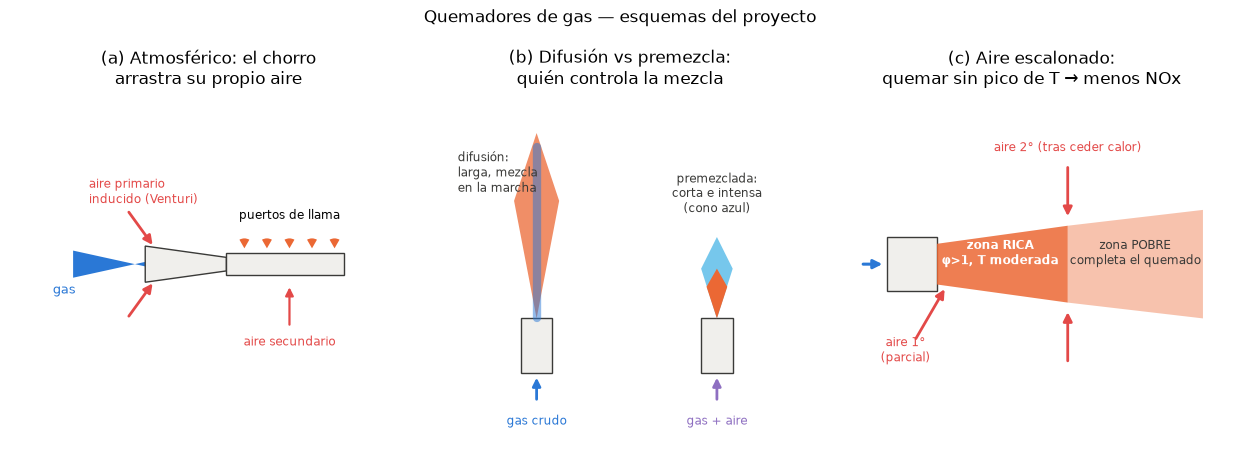

In [14]:
# Diagrama propio — quemadores de gas (reemplaza 5 escaneos)
fig, axs = plt.subplots(1, 3, figsize=(12.5, 4.6))
ax = axs[0]  # atmosférico (venturi)
ax.add_patch(Polygon([(0.8, 2.7), (2.4, 3.05), (2.4, 2.95), (0.8, 3.3)][::-1], fc=COL["fuel"], ec="none"))
ax.add_patch(Polygon([(2.4, 2.6), (4.2, 2.85), (4.2, 3.15), (2.4, 3.4)], fc="#f0efec", ec=COL["tinta"]))
ax.add_patch(Rectangle((4.2, 2.75), 2.6, 0.5, fc="#f0efec", ec=COL["tinta"]))
for dy in (-0.75, 0.75):
    ax.add_patch(FancyArrowPatch((2.0, 3.0 + dy * 1.6), (2.6, 3.0 + dy * 0.5),
                                 arrowstyle="-|>", mutation_scale=13, color=COL["O2"], lw=2))
ax.text(1.15, 4.35, "aire primario\ninducido (Venturi)", fontsize=8.5, color=COL["O2"])
ax.text(0.35, 2.35, "gas", fontsize=9.5, color=COL["fuel"])
for px in np.linspace(4.6, 6.6, 5):
    ax.add_patch(Wedge((px, 3.35), 0.22, 60, 120, fc=COL["llama"], ec="none"))
ax.text(5.6, 4.0, "puertos de llama", fontsize=8.5, ha="center")
ax.add_patch(FancyArrowPatch((5.6, 1.6), (5.6, 2.55), arrowstyle="-|>", mutation_scale=12,
                             color=COL["O2"], lw=1.6))
ax.text(5.6, 1.2, "aire secundario", fontsize=8.5, ha="center", color=COL["O2"])
ax.set_title("(a) Atmosférico: el chorro\narrastra su propio aire")
ax = axs[1]  # difusión vs premezcla
ax.add_patch(Rectangle((1.6, 0.6), 0.7, 1.2, fc="#f0efec", ec=COL["tinta"]))
ax.plot([1.95, 1.95], [1.8, 5.6], color=COL["fuel"], lw=6, alpha=0.5, solid_capstyle="round")
ax.add_patch(Polygon([(1.95, 1.8), (1.45, 4.4), (1.95, 5.9), (2.45, 4.4)], fc=COL["llama"], alpha=0.75, ec="none"))
ax.text(0.2, 4.6, "difusión:\nlarga, mezcla\nen la marcha", fontsize=8.5, ha="left", color=COL["tinta"])
ax.add_patch(Rectangle((5.6, 0.6), 0.7, 1.2, fc="#f0efec", ec=COL["tinta"]))
ax.add_patch(Polygon([(5.95, 1.8), (5.6, 2.9), (5.95, 3.6), (6.3, 2.9)], fc="#67c1ea", alpha=0.9, ec="none"))
ax.add_patch(Polygon([(5.95, 1.8), (5.72, 2.5), (5.95, 2.9), (6.18, 2.5)], fc=COL["llama"], ec="none"))
ax.text(5.95, 4.15, "premezclada:\ncorta e intensa\n(cono azul)", fontsize=8.5, ha="center", color=COL["tinta"])
ax.add_patch(FancyArrowPatch((1.95, -0.05), (1.95, 0.55), arrowstyle="-|>", mutation_scale=12,
                             color=COL["fuel"], lw=2))
ax.add_patch(FancyArrowPatch((5.95, -0.05), (5.95, 0.55), arrowstyle="-|>", mutation_scale=12,
                             color="#8e6fc1", lw=2))
ax.text(1.95, -0.55, "gas crudo", fontsize=8.5, ha="center", color=COL["fuel"])
ax.text(5.95, -0.55, "gas + aire", fontsize=8.5, ha="center", color="#8e6fc1")
ax.set_title("(b) Difusión vs premezcla:\nquién controla la mezcla")
ax = axs[2]  # aire escalonado
ax.add_patch(Rectangle((0.6, 2.4), 1.1, 1.2, fc="#f0efec", ec=COL["tinta"]))
ax.add_patch(Polygon([(1.7, 2.55), (4.6, 2.15), (4.6, 3.85), (1.7, 3.45)], fc=COL["llama"], alpha=0.85, ec="none"))
ax.add_patch(Polygon([(4.6, 2.15), (7.6, 1.8), (7.6, 4.2), (4.6, 3.85)], fc=COL["llama"], alpha=0.4, ec="none"))
ax.text(3.1, 3.0, "zona RICA\nφ>1, T moderada", fontsize=8.5, ha="center", color="white", fontweight="bold")
ax.text(6.1, 3.0, "zona POBRE\ncompleta el quemado", fontsize=8.5, ha="center", color=COL["tinta"])
ax.add_patch(FancyArrowPatch((0.0, 3.0), (0.55, 3.0), arrowstyle="-|>", mutation_scale=13,
                             color=COL["fuel"], lw=2.2))
ax.add_patch(FancyArrowPatch((1.2, 1.3), (1.9, 2.5), arrowstyle="-|>", mutation_scale=13,
                             color=COL["O2"], lw=2))
ax.text(1.0, 0.85, "aire 1°\n(parcial)", fontsize=8.5, color=COL["O2"], ha="center")
for sx in (4.6,):
    ax.add_patch(FancyArrowPatch((sx, 5.2), (sx, 4.0), arrowstyle="-|>", mutation_scale=13,
                                 color=COL["O2"], lw=2))
    ax.add_patch(FancyArrowPatch((sx, 0.8), (sx, 2.0), arrowstyle="-|>", mutation_scale=13,
                                 color=COL["O2"], lw=2))
ax.text(4.6, 5.5, "aire 2° (tras ceder calor)", fontsize=8.5, ha="center", color=COL["O2"])
ax.text(4.1, 6.4, " ", fontsize=8)
ax.set_title("(c) Aire escalonado:\nquemar sin pico de T → menos NOx")
for ax in axs:
    ax.set_xlim(-0.6, 8.2); ax.set_ylim(-1.0, 6.8); ax.axis("off")
plt.suptitle("Quemadores de gas — esquemas del proyecto", fontsize=12)
plt.tight_layout(); plt.show()

In [15]:
# WIDGET 7 — aire escalonado: temperatura por zonas y NOx térmico (Zeldovich)
E_R_NOX = 38370.0    # K — energía de activación efectiva O + N2 (Zeldovich térmico)

def T_zona(E_J, corr):  # temperatura que absorbe E con la mezcla 'corr' {fluido: mol}
    def resid(T):
        return sum(n * (h_sens(f, T) - h_sens(f, 298.15)) for f, n in corr.items() if n > 0) - E_J
    return brentq(resid, 300, 3190)

def aire_escalonado(f_prim=0.75, perdida=0.30):
    # CH4 + aire escalonado: zona 1 recibe f_prim·aire_esteq; zona 2 completa a λ=1.05
    lam_tot = 1.05
    E1 = min(f_prim, 1.0) * DHC_CH4                       # calor liberado en zona rica
    z1 = {"CO2": min(f_prim, 1.0), "Water": 2 * min(f_prim, 1.0),
          "Methane": 1 - min(f_prim, 1.0), "Nitrogen": 3.76 * NU_CH4 * f_prim,
          "Oxygen": max(f_prim - 1.0, 0.0) * NU_CH4}
    T1 = T_zona(E1, z1)
    E2 = (1 - perdida) * E1 + (DHC_CH4 - E1)              # zona 2: resto del calor + lo no perdido
    z2 = {"CO2": 1.0, "Water": 2.0, "Nitrogen": 3.76 * NU_CH4 * lam_tot,
          "Oxygen": (lam_tot - 1) * NU_CH4}
    T2 = T_zona(E2, z2)
    T_pico = max(T1, T2)
    # referencia sin escalonar (f=1, sin pérdida intermedia)
    T_ref = T_zona(DHC_CH4, z2)
    NOx_rel = np.exp(-E_R_NOX / T_pico) / np.exp(-E_R_NOX / T_ref) * 100
    # curva NOx(f) para la pérdida elegida
    fs = np.linspace(0.5, 1.0, 26)
    NOx_c = []
    for f in fs:
        E1c = f * DHC_CH4
        z1c = {"CO2": f, "Water": 2 * f, "Methane": 1 - f, "Nitrogen": 3.76 * NU_CH4 * f}
        T1c = T_zona(E1c, z1c)
        T2c = T_zona((1 - perdida) * E1c + (DHC_CH4 - E1c), z2)
        NOx_c.append(np.exp(-E_R_NOX / max(T1c, T2c)) / np.exp(-E_R_NOX / T_ref) * 100)
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.5, 4.9))
    ax0.bar(["zona 1\n(rica)", "zona 2\n(pobre)", "sin escalonar\n(referencia)"],
            [T1, T2, T_ref], color=[COL["llama"], "#f4b183", COL["N2"]], width=0.6)
    for xi, T in enumerate([T1, T2, T_ref]):
        ax0.text(xi, T + 25, f"{T:.0f} K", ha="center", fontsize=10, color=COL["tinta"])
    ax0.set_ylabel("temperatura de zona [K]")
    ax0.set_title(f"f aire primario = {f_prim:.2f} | pérdida entre zonas = {perdida:.0%}")
    ax0.grid(axis="y", alpha=0.25); ax0.spines[["top", "right"]].set_visible(False)
    ax1.plot(fs, NOx_c, color=COL["SO2"], lw=2.4)
    ax1.axhspan(40, 80, color=COL["H2O"], alpha=0.12)
    ax1.text(0.51, 60, "reducción típica\n20-60 % (Baukal)", fontsize=9, color=COL["tinta"], va="center")
    if f_prim <= 1.0:
        ax1.plot(f_prim, NOx_rel, "o", ms=10, color=COL["O2"], mec="white", mew=1.5)
        ax1.annotate(f"NOx = {NOx_rel:.0f} % del caso sin escalonar\n(T pico {T_pico:.0f} K vs {T_ref:.0f} K)",
                     xy=(f_prim, NOx_rel), xytext=(0.55, min(NOx_rel + 25, 92)), fontsize=10,
                     color=COL["tinta"], arrowprops=dict(arrowstyle="->", color=COL["tinta"], lw=1))
    ax1.set_xlabel("fracción de aire primario f"); ax1.set_ylabel("NOx térmico relativo [%]")
    ax1.set_ylim(0, 110)
    ax1.set_title("NOx ∝ e$^{-38370/T_{pico}}$: evitar el pico de T")
    ax1.grid(alpha=0.25); ax1.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.show()

interact(aire_escalonado,
         f_prim=FloatSlider(0.75, min=0.5, max=1.0, step=0.01, description="f primario"),
         perdida=FloatSlider(0.30, min=0.0, max=0.5, step=0.02, description="pérdida q₁₂"));

interactive(children=(FloatSlider(value=0.75, description='f primario', max=1.0, min=0.5, step=0.01), FloatSli…

**Explora con el widget:** con $f = 1$ y pérdida 0 se recupera el caso sin escalonar (NOx = 100 %). Al bajar $f$, la zona rica no puede alcanzar la temperatura adiabática (le falta O₂) y la pobre recibe gases ya enfriados: el **pico** de temperatura desaparece y el NOx cae exponencialmente — la banda verde marca el 20-60 % de reducción típica citado en la prosa. El precio: llamas más largas y riesgo de inquemados si $f$ baja demasiado (el mismo compromiso $\eta$ vs emisiones de toda la lección).

### 8.5 Combustibles No Fósiles

__Hidrógeno__ — Fuente: puede producirse por reformado de gas natural (con emisiones de CO₂) o mediante electrólisis del agua (energía eléctrica separa H₂ y O₂). Ventajas: su combustión produce principalmente vapor de agua, sin emisiones de CO₂ en el uso final. Desafíos: almacenamiento y transporte complicados (requiere alta presión o muy baja temperatura), producción aún costosa si se quiere bajo o cero carbono. *(Su cinética H₂/O₂ fue el primer ejemplo de la Lección 8.)*

__Biogás__ — Surge de la descomposición anaeróbica de residuos orgánicos (agroindustriales, vertederos, etc.) — *el ciclo del carbono de la Lección 3 en acción*.

__Syngas (gas de síntesis)__ — Mezcla de H₂ y CO procedente de gasificación de carbón, biomasa o residuos.

Residuos sólidos urbanos (RSU) y biomasa: se pueden procesar para obtener combustibles sólidos, líquidos o gaseosos — la **Lección 8b** modela la combustión del raquis y la fibra de palma, los dos residuos de biomasa más abundantes de la agroindustria colombiana.

## 9. Ejercicios

1. **Parrilla viajera:** un carbón bituminoso con 30 % de ceniza y 20 % de humedad incumple los límites de diseño de la §6.2. Usando el widget de la §3 (núcleo menguante), explique *físicamente* por qué el exceso de ceniza obliga a reducir la velocidad de la cinta (tiempo de residencia), y estime cuánto crece el tiempo de conversión al duplicar $\tau_a$.
2. **Atomizador:** con el widget de la §7.2, dimensione un atomizador Y para 1500 kg/h de fuel oil con $P_0$ = 3 MPa y vapor a 1 MPa. Verifique que $d_2/d_1$ y el número de orificios queden en el rango recomendado y reporte el tamaño de gota. ¿Cuánto cambia $d_{drop}$ si el vapor cae a 0.5 MPa?
3. **Aire escalonado:** su caldera opera con $f = 0.8$ y pérdida intermedia del 25 %. Con el widget de la §8.3, reporte la reducción de NOx y las temperaturas de zona. ¿Qué pasa con los inquemados si baja $f$ a 0.55? Relacione con la eficiencia de combustión $\eta = Q_f/Q_{ch}$ de la Lección 7.

## Conclusión

Vista desde la teoría, la tecnología de combustión deja de ser un catálogo de aparatos: **cada máquina es una respuesta a un obstáculo físico-químico concreto**. Las parrillas administran el contacto y la ceniza; el lecho fluidizado ataca los cuatro obstáculos a la vez y por eso domina la combustión de sólidos difíciles; el atomizador es la ley $d^2$ hecha acero; los quemadores de gas son máquinas de mezclar; y el aire escalonado sacrifica el pico de temperatura — que la Lección 7 enseñó a calcular — para no pagar el NOx que la cinética de Arrhenius cobra exponencialmente. El diseño real es siempre el mismo compromiso: **contacto estequiométrico, a la temperatura correcta, durante el tiempo suficiente, con la mezcla necesaria** — las tres T sobre los cuatro obstáculos.

---
### Bibliografía
- Basu, P., Kefa, C. & Jestin, L. (2000). *Boilers and Burners: Design and Theory*. Springer. doi:10.1007/978-1-4612-1250-8
- Baukal Jr., C. E. (Ed.) (2013). *The John Zink Hamworthy Combustion Handbook*, 2ª ed., Vol. 3 – Applications. CRC Press. doi:10.1201/b15040
- Levenspiel, O. (1999). *Chemical Reaction Engineering*, 3ª ed. Wiley — modelo de núcleo menguante.
- Çengel, Y. A. & Boles, M. A. (2015). *Termodinámica*, 8ª ed. McGraw-Hill.
- Bell, I. H. et al. (2014). CoolProp. *Ind. Eng. Chem. Res.*, 53(6), 2498–2508.